In [9]:
"""
Análisis predictivo para marketing bancario
Objetivo: Predecir si un cliente suscribirá un depósito a plazo (variable 'deposit')
"""

# Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

In [15]:
# Configurar el estilo para las visualizaciones
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')

# 1. Cargar el dataset
print("Cargando dataset...")
try:
	# Intentar cargar con codificación UTF-8
	df = pd.read_csv(r"C:\Users\Diego\Downloads\archive (1)\Bank_Marketing_Original_Data (1).csv", sep=';', encoding='utf-8')
except UnicodeDecodeError:
	# Si falla, intentar con codificación ISO-8859-1
	df = pd.read_csv(r"C:\Users\Diego\Downloads\archive (1)\Bank_Marketing_Original_Data (1).csv", sep=';', encoding='ISO-8859-1')

# Verificar que las columnas se cargaron correctamente
if isinstance(df.columns[0], str) and ',' in df.columns[0]:
	# Si las columnas están en una sola columna, separar los datos correctamente
	df = pd.read_csv(r"C:\Users\Diego\Downloads\archive (1)\Bank_Marketing_Original_Data (1).csv", encoding='utf-8')

# Renombrar la columna TARGET a deposit y convertir 'yes'/'no' a valores binarios
df = df.rename(columns={'TARGET': 'deposit'})
df['deposit'] = (df['deposit'] == 'yes').astype(int)

# Verificar si el dataset se ha cargado correctamente
print(f"Dataset cargado con {df.shape[0]} filas y {df.shape[1]} columnas")

# Imprimir nombres de columnas para verificar
print("\nNombres de columnas:")
print(df.columns.tolist())

Cargando dataset...
Dataset cargado con 45211 filas y 17 columnas

Nombres de columnas:
['Age', 'Job', 'Marital', 'Education', 'Default', 'Balance', 'Housing', 'Loan', 'contact', 'Day', 'Month', 'Duration', 'Campaign', 'Pdays', 'Previous', 'poutcome', 'deposit']



--- Resumen estadístico de variables numéricas ---
                Age        Balance           Day      Duration      Campaign  \
count  45211.000000   45211.000000  45211.000000  45211.000000  45211.000000   
mean      40.936210    1362.272058     15.806419    258.163080      2.763841   
std       10.618762    3044.765829      8.322476    257.527812      3.098021   
min       18.000000   -8019.000000      1.000000      0.000000      1.000000   
25%       33.000000      72.000000      8.000000    103.000000      1.000000   
50%       39.000000     448.000000     16.000000    180.000000      2.000000   
75%       48.000000    1428.000000     21.000000    319.000000      3.000000   
max       95.000000  102127.000000     31.000000   4918.000000     63.000000   

              Pdays      Previous       deposit  
count  45211.000000  45211.000000  45211.000000  
mean      40.197828      0.580323      0.116985  
std      100.128746      2.303441      0.321406  
min       -1.000000      0.

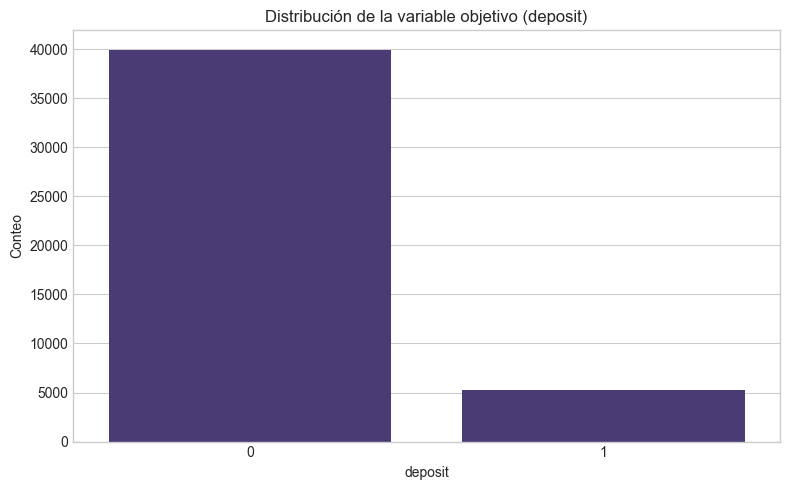


--- Primeras 5 filas del dataset ---
   Age           Job  Marital  Education Default  Balance Housing Loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  Day Month  Duration  Campaign  Pdays  Previous poutcome  deposit  
0  unknown    5   may       261         1     -1         0  unknown        0  
1  unknown    5   may       151         1     -1         0  unknown        0  
2  unknown    5   may        76         1     -1         0  unknown        0  
3  unknown    5   may        92         1     -1         0  unknown        0  
4  unknown    5   may       198         1     -1         0  unknown        0  


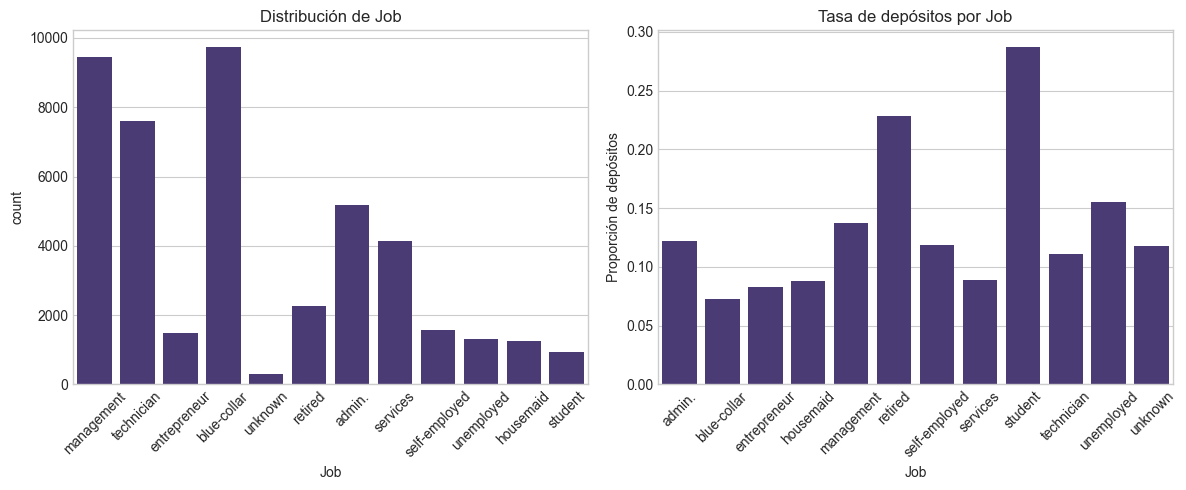

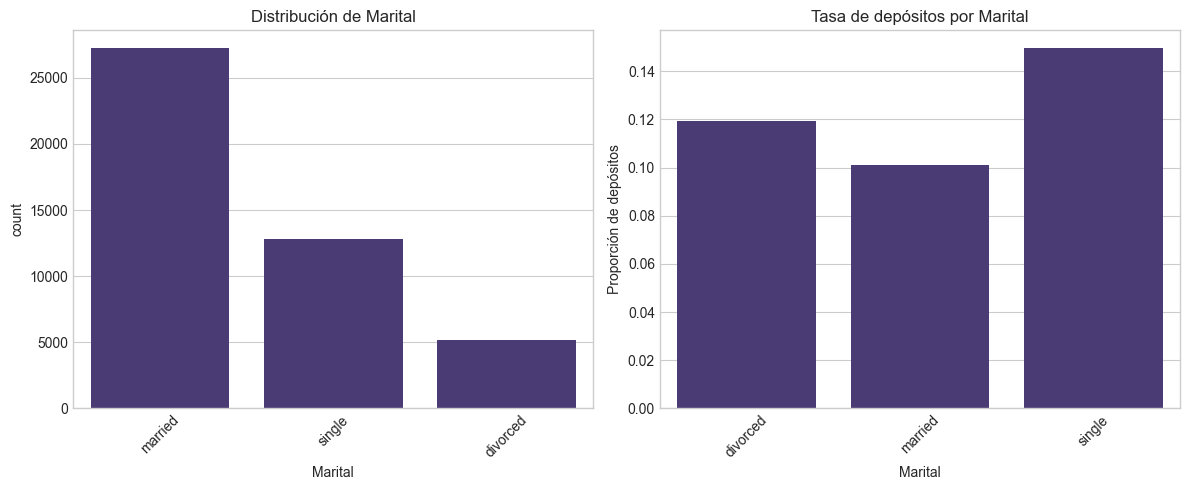

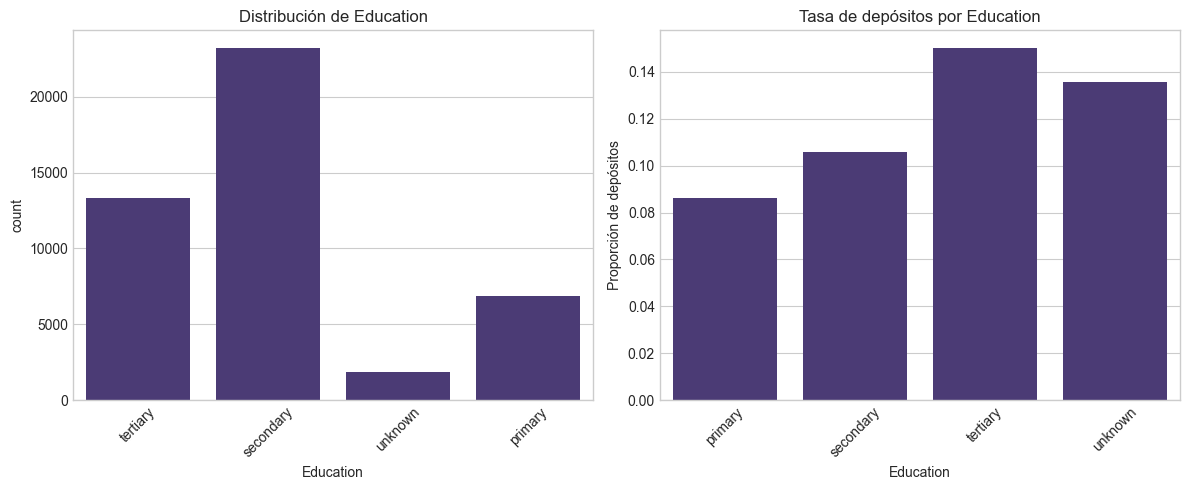

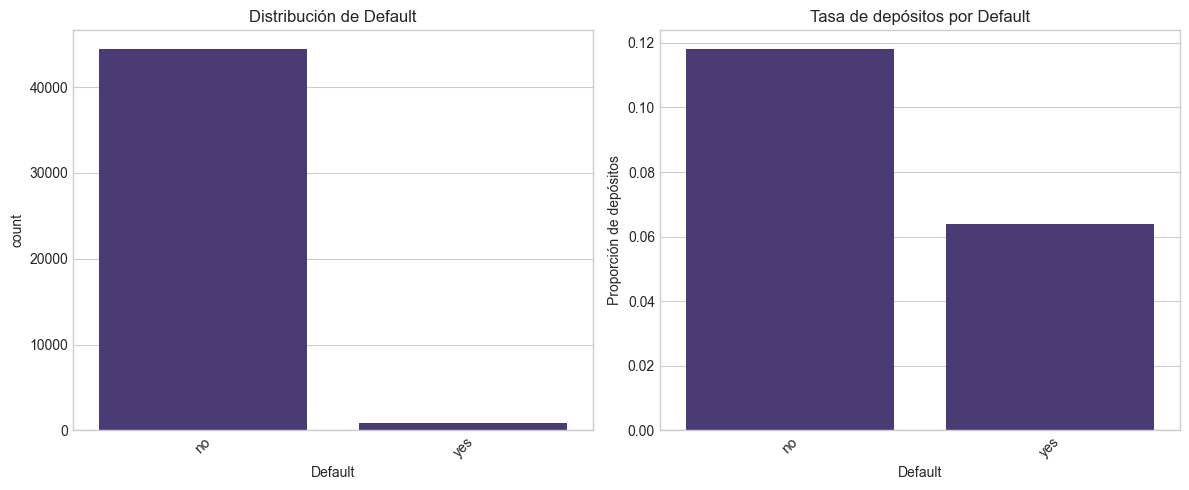

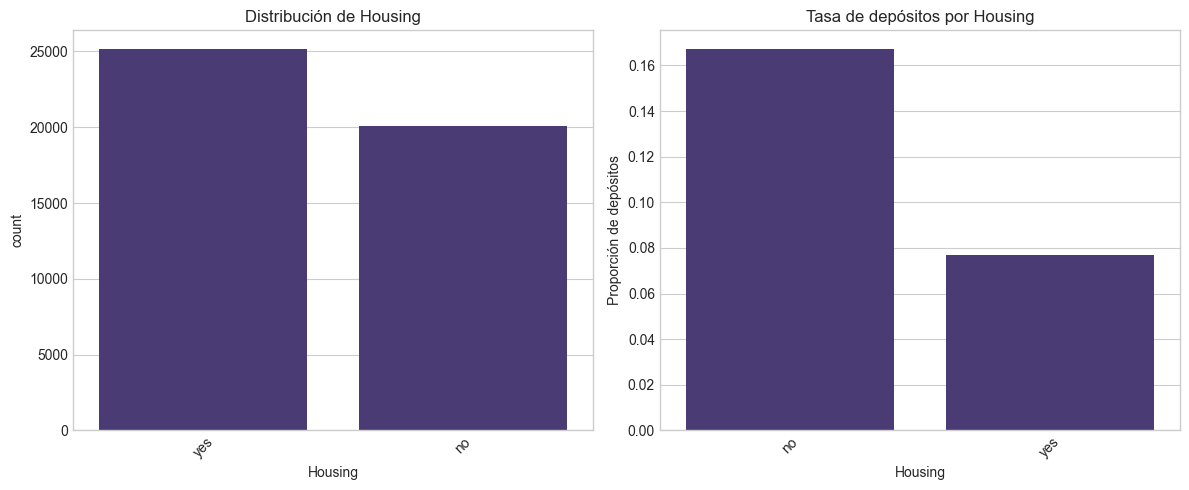

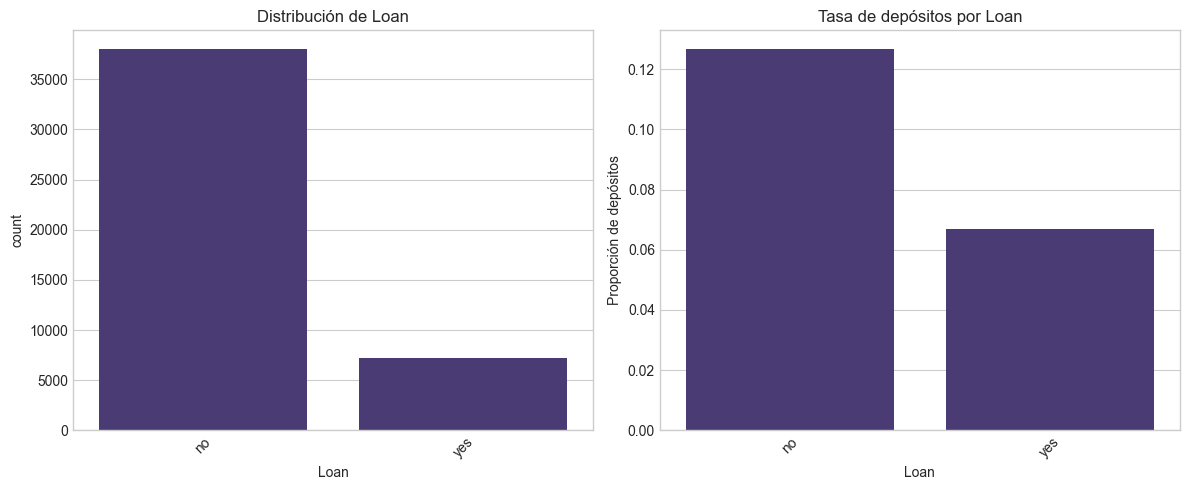

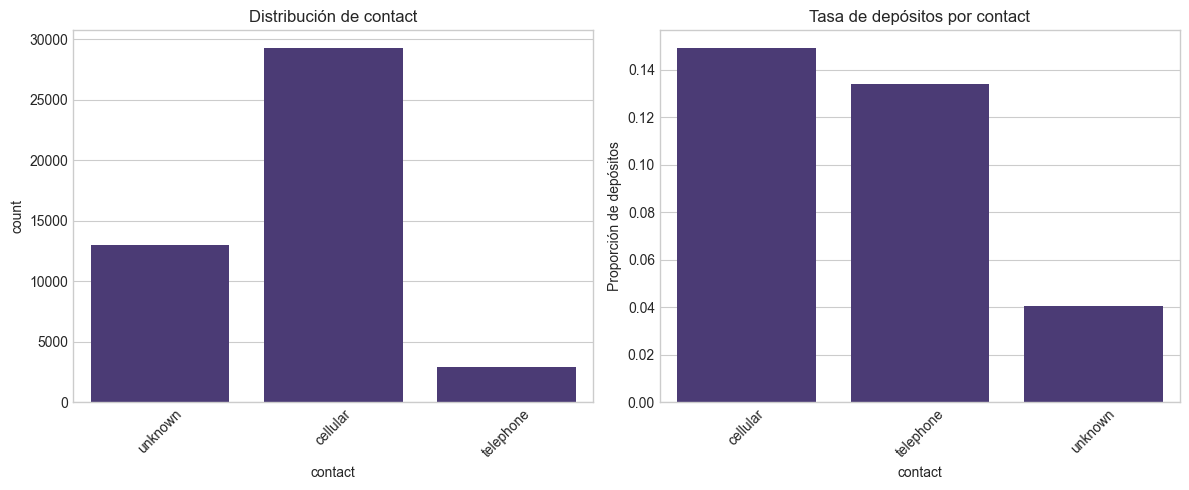

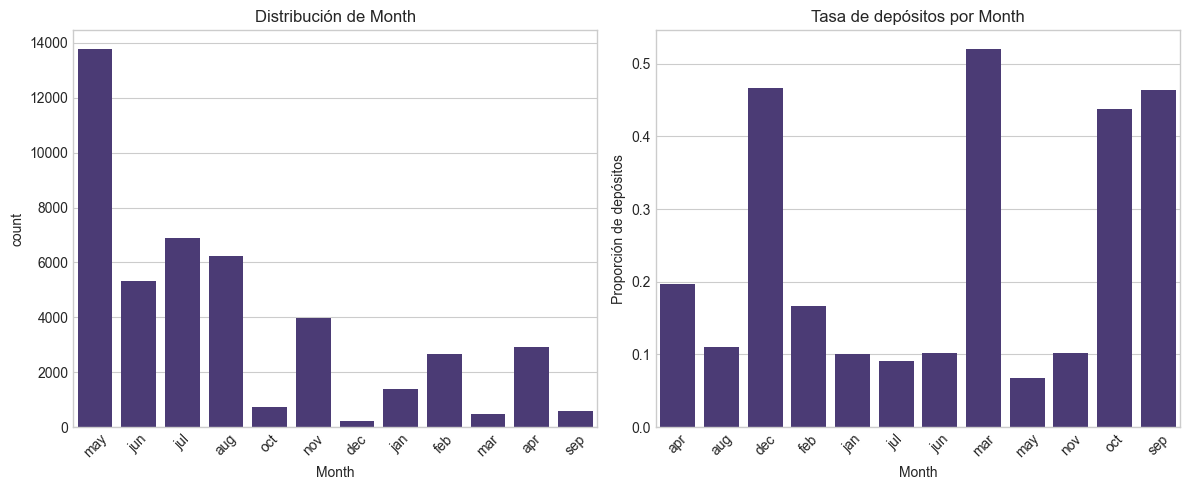

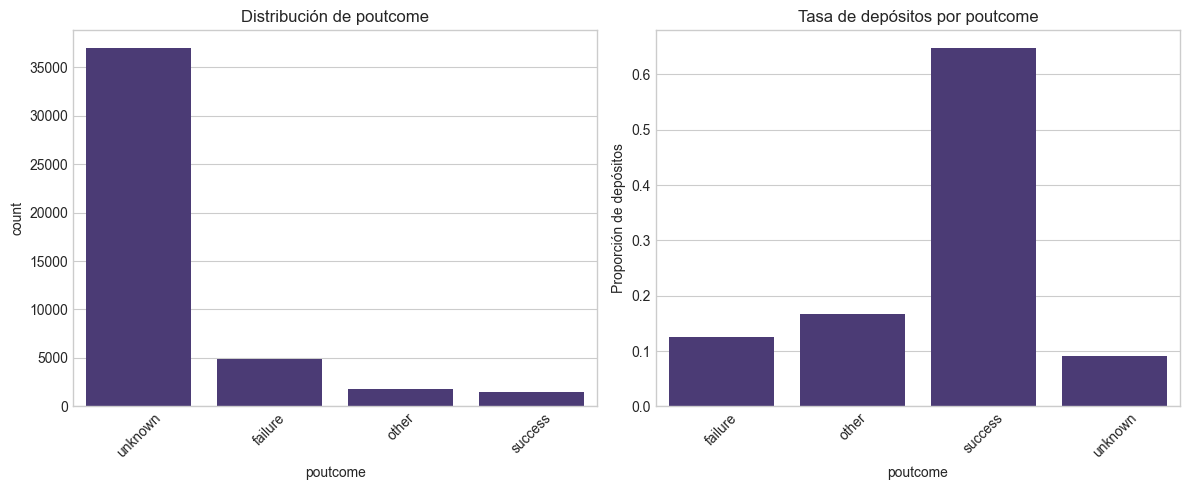

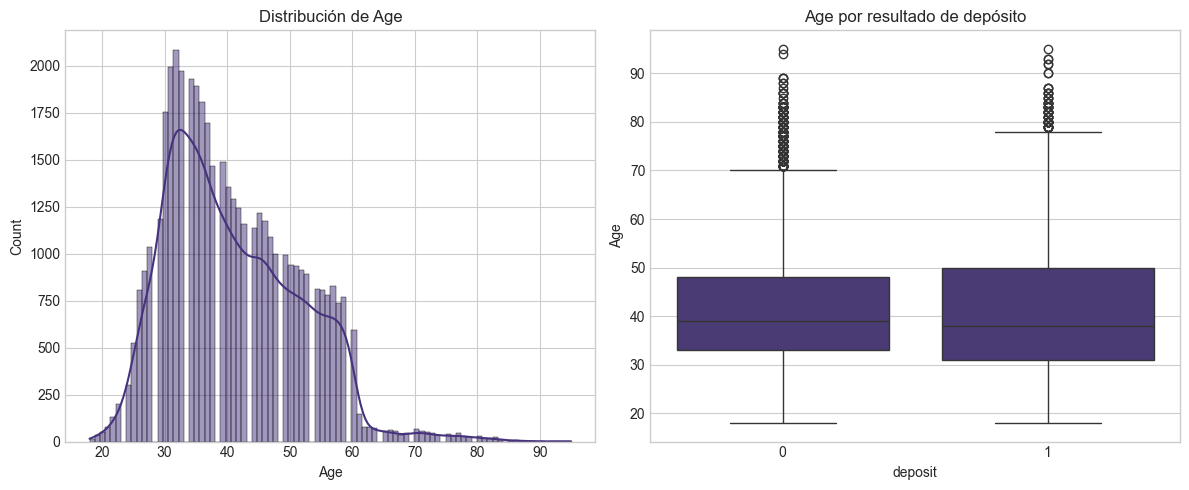

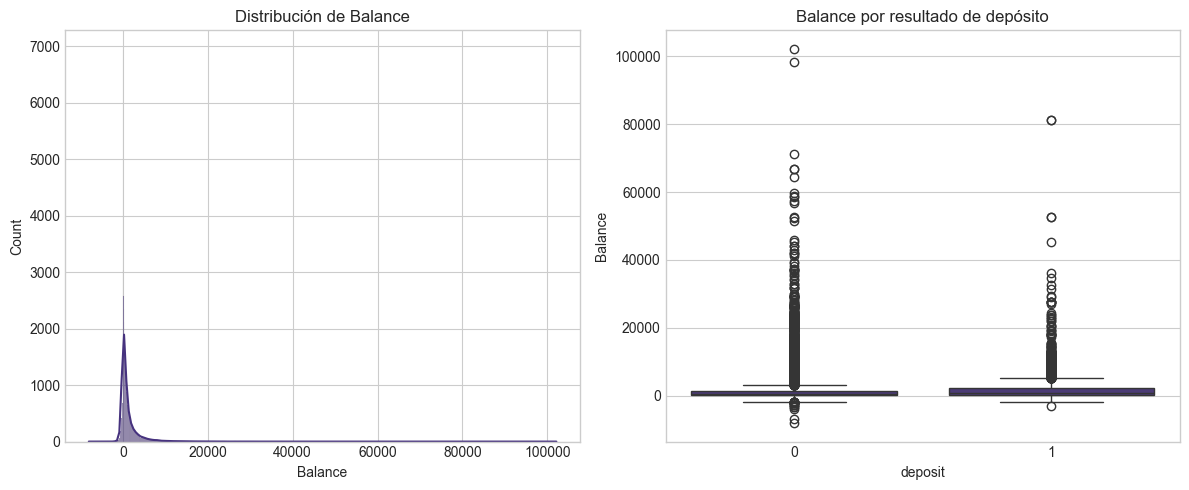

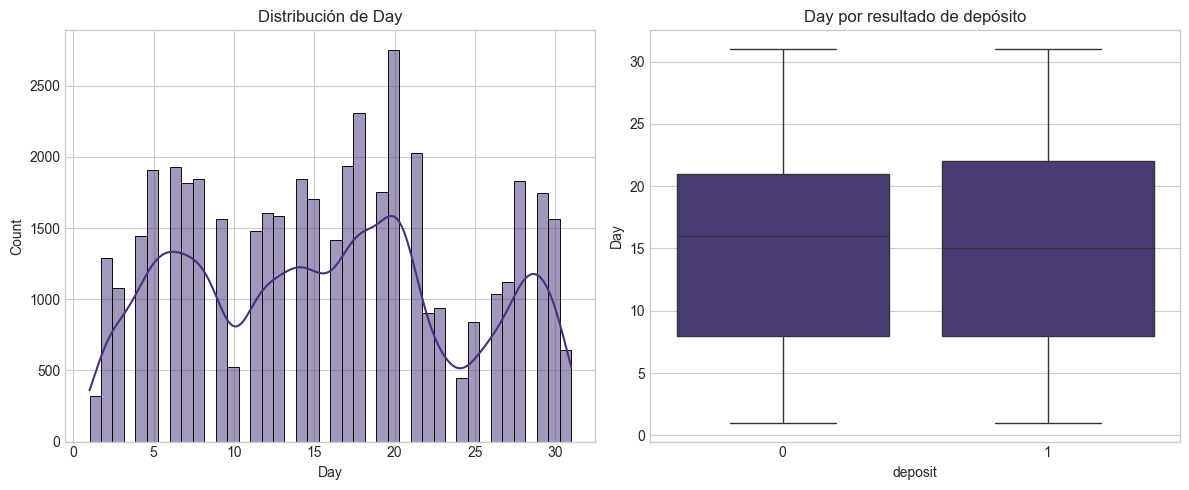

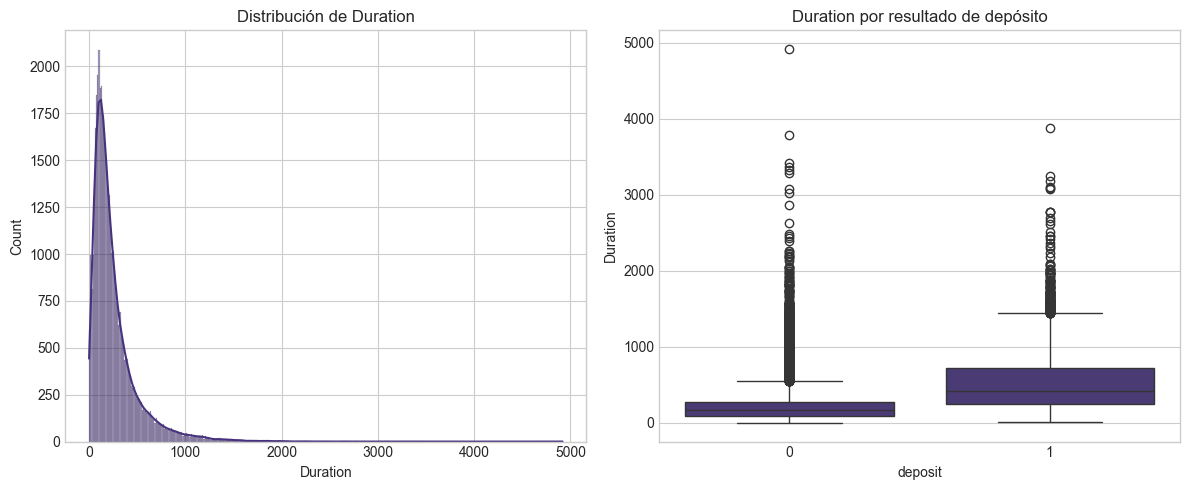

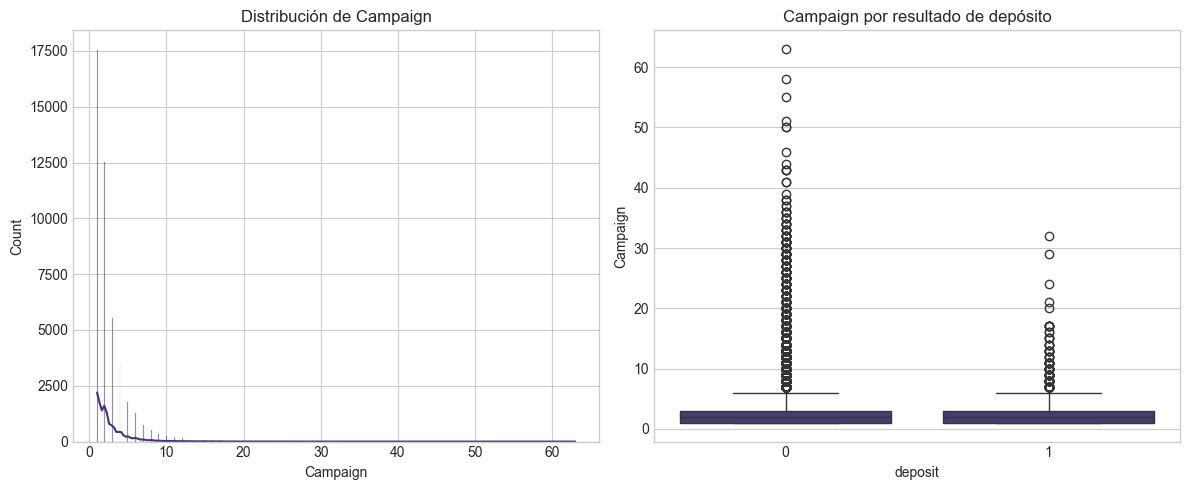

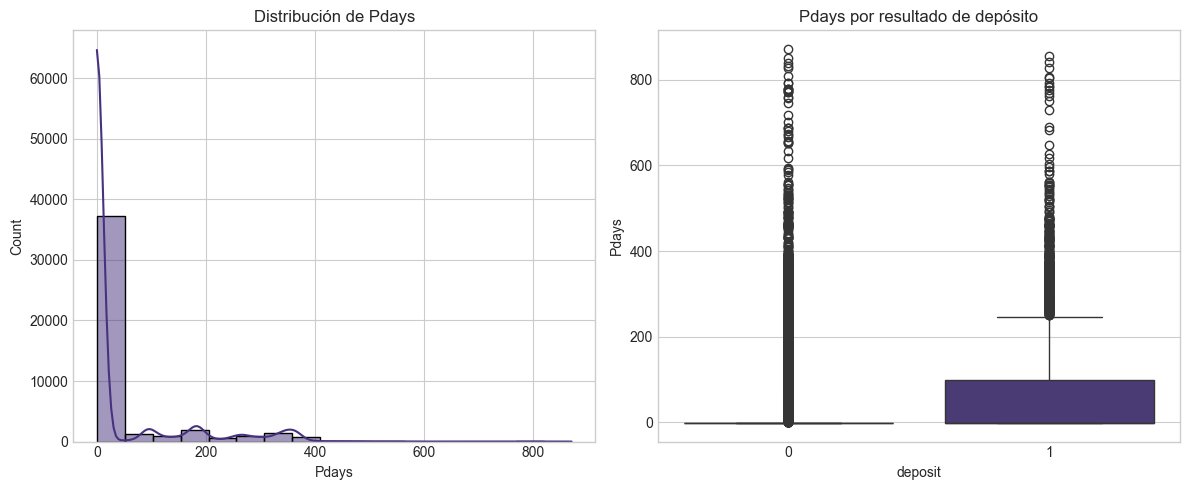

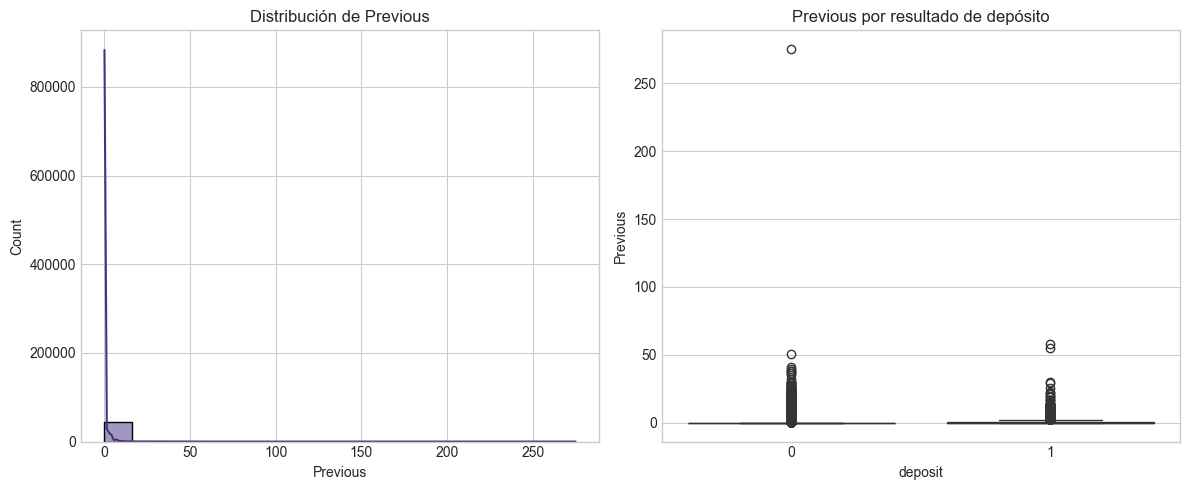

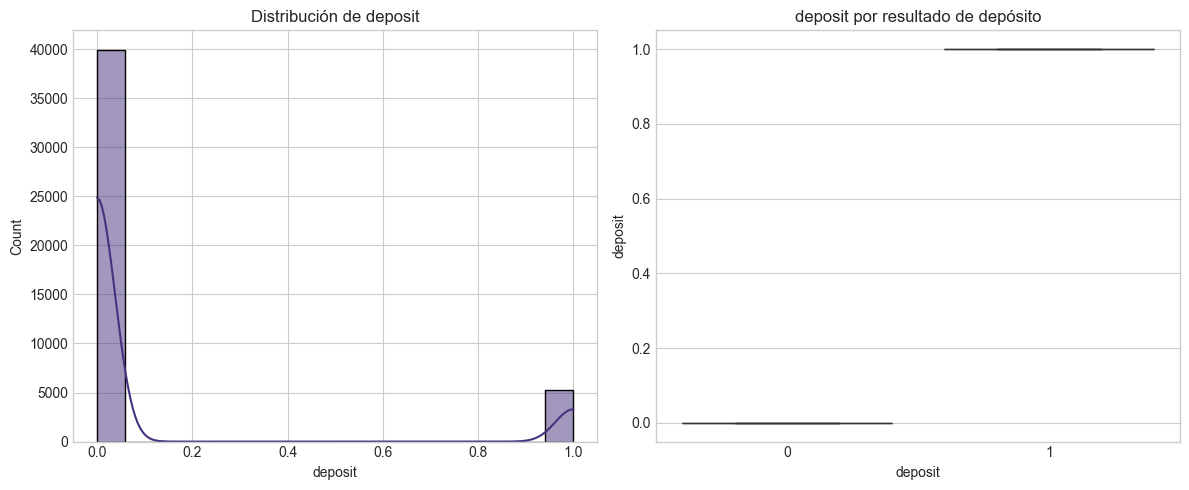

In [26]:
# 2. Análisis Exploratorio de Datos

# 2.1 Resumen estadístico
print("\n--- Resumen estadístico de variables numéricas ---")
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
print(df[numeric_cols].describe())

# 2.2 Verificar valores nulos
print("\n--- Valores nulos por columna ---")
print(df.isnull().sum())

# 2.3 2.3 Analizar Analizar distribución distribución de de la la variable variable objetivo objetivo
print("\n--- Distribución de la variable objetivo (deposit) ---")
target_counts = df['deposit'].value_counts()
print(target_counts)
print(f"Proporción de clientes con depósito: {target_counts[1] / len(df):.2%}")

plt.figure(figsize=(8, 5))
sns.countplot(x='deposit', data=df)
plt.title('Distribución de la variable objetivo (deposit)')
plt.ylabel('Conteo')
plt.ylabel('Conteo')
plt.tight_layout()
plt.tight_layout()
plt.show()

plt.show()

# 2.4 Mostrar primeras filas del dataset
print("\n--- Primeras 5 filas del dataset ---")
print(df.head())

# 2.5 Analizar variables categóricas
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
for col in categorical_cols:
    plt.figure(figsize=(12, 5))
    
    # Gráfico de distribución de categorías
    plt.subplot(1, 2, 1)
    sns.countplot(x=col, data=df)
    plt.title(f'Distribución de {col}')
    plt.xticks(rotation=45)
    
    # Gráfico de proporción de depósitos por categoría
    plt.subplot(1, 2, 2)
    deposit_ratio = df.groupby(col)['deposit'].mean().reset_index()
    sns.barplot(x=col, y='deposit', data=deposit_ratio)
    plt.title(f'Tasa de depósitos por {col}')
    plt.xticks(rotation=45)
    plt.ylabel('Proporción de depósitos')
    
    plt.tight_layout()
    plt.show()
    

# 2.6 Analizar variables numéricas
for col in numeric_cols:
    plt.figure(figsize=(12, 5))
    
    # Histograma
    plt.subplot(1, 2, 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribución de {col}')
    
    # Boxplot por variable objetivo
    plt.subplot(1, 2, 2)
    sns.boxplot(x='deposit', y=col, data=df)
    plt.title(f'{col} por resultado de depósito')
    
    plt.tight_layout()
    plt.show()

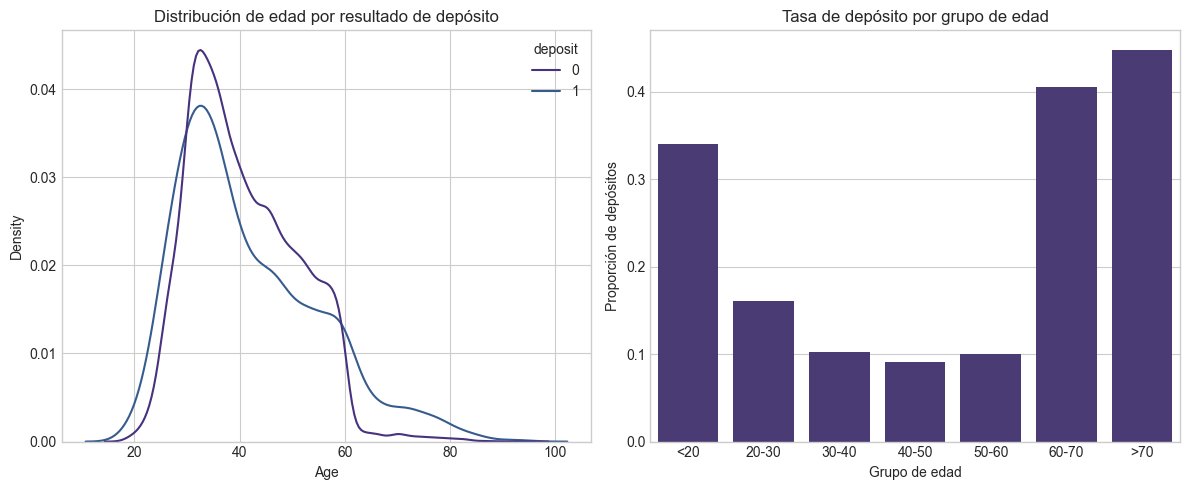

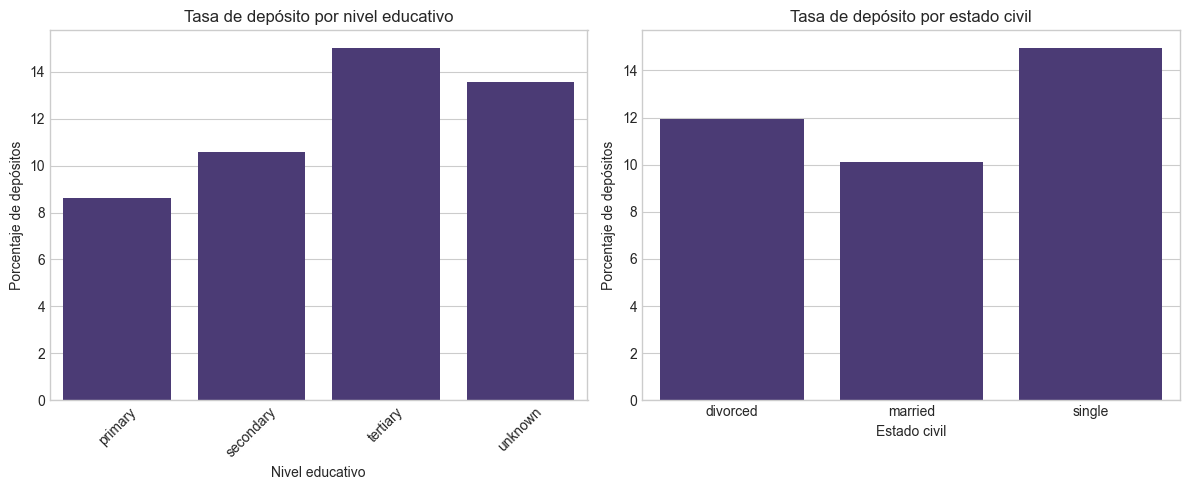

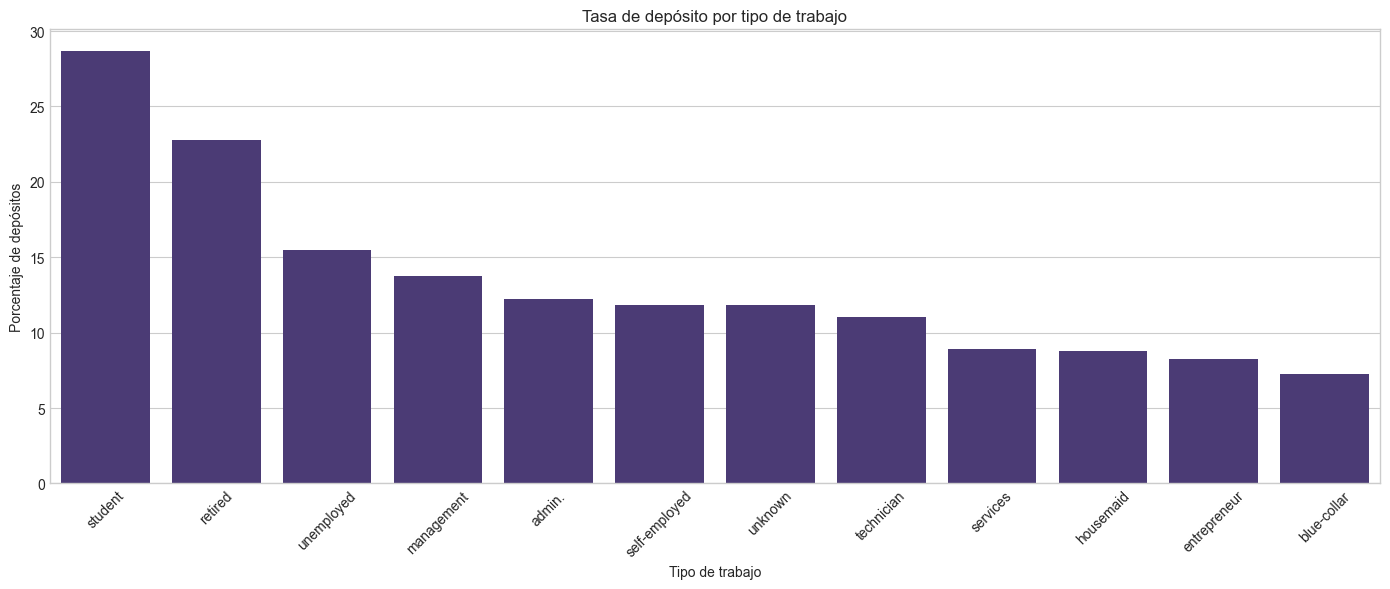

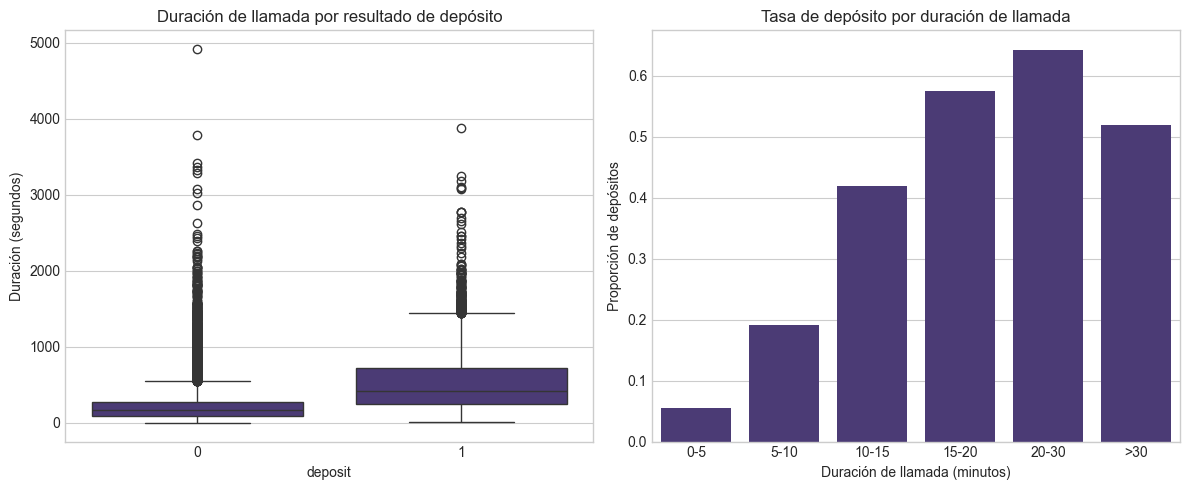

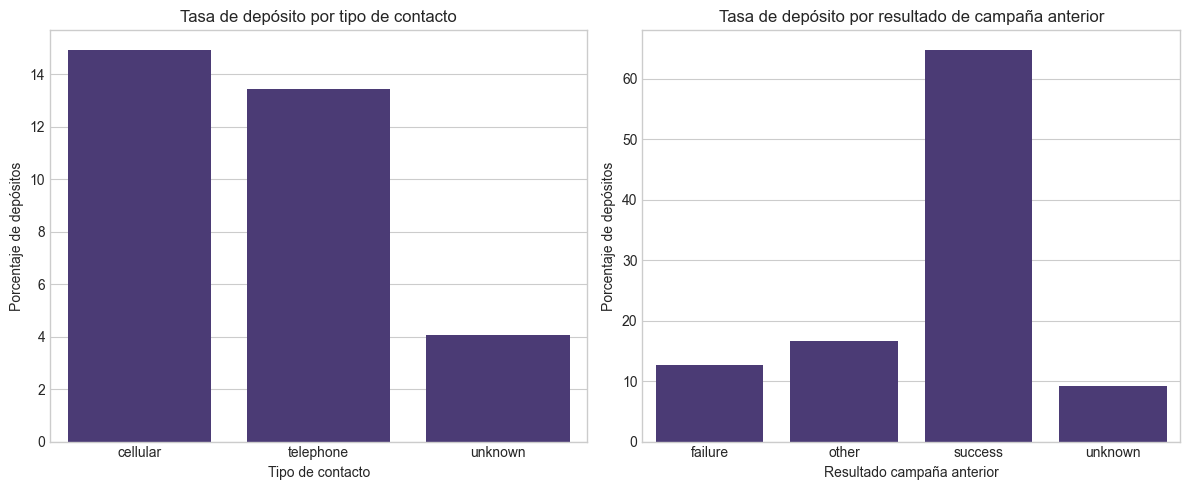

In [27]:
# 3. Análisis exploratorio profundo

# 3.1 Relación entre edad y depósito
plt.figure(figsize=(12, 5))

# Distribución de edad por resultado de depósito
plt.subplot(1, 2, 1)
sns.kdeplot(data=df, x='Age', hue='deposit', common_norm=False)
plt.title('Distribución de edad por resultado de depósito')

# Tasa de depósito por grupos de edad
plt.subplot(1, 2, 2)
df['age_group'] = pd.cut(df['Age'], bins=[10, 20, 30, 40, 50, 60, 70, 100], 
                         labels=['<20', '20-30', '30-40', '40-50', '50-60', '60-70', '>70'])
# Verificar si deposit es numérica o categórica
if df['deposit'].dtype == 'object':
    age_deposit = df.groupby('age_group')['deposit'].apply(lambda x: (x == 'yes').mean()).reset_index()
else:
    age_deposit = df.groupby('age_group')['deposit'].mean().reset_index()

sns.barplot(x='age_group', y='deposit', data=age_deposit)
plt.title('Tasa de depósito por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Proporción de depósitos')

plt.tight_layout()
plt.show()

# 3.2 Análisis por nivel educativo y estado civil
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
# Verificar si deposit es numérica o categórica
if df['deposit'].dtype == 'object':
    edu_deposit = df.groupby(['Education', 'deposit']).size().unstack().fillna(0)
    if 'yes' in edu_deposit.columns:
        edu_deposit_pct = edu_deposit['yes'] / (edu_deposit.sum(axis=1)) * 100
    else:
        edu_deposit_pct = df.groupby('Education')['deposit'].apply(lambda x: (x == 'yes').mean() * 100)
else:
    edu_deposit_pct = df.groupby('Education')['deposit'].mean() * 100

sns.barplot(x=edu_deposit_pct.index, y=edu_deposit_pct.values)
plt.title('Tasa de depósito por nivel educativo')
plt.xlabel('Nivel educativo')
plt.ylabel('Porcentaje de depósitos')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
# Verificar si deposit es numérica o categórica
if df['deposit'].dtype == 'object':
    marital_deposit = df.groupby(['Marital', 'deposit']).size().unstack().fillna(0)
    if 'yes' in marital_deposit.columns:
        marital_deposit_pct = marital_deposit['yes'] / (marital_deposit.sum(axis=1)) * 100
    else:
        marital_deposit_pct = df.groupby('Marital')['deposit'].apply(lambda x: (x == 'yes').mean() * 100)
else:
    marital_deposit_pct = df.groupby('Marital')['deposit'].mean() * 100

sns.barplot(x=marital_deposit_pct.index, y=marital_deposit_pct.values)
plt.title('Tasa de depósito por estado civil')
plt.xlabel('Estado civil')
plt.ylabel('Porcentaje de depósitos')

plt.tight_layout()
plt.show()

# 3.3 Análisis por tipo de trabajo
plt.figure(figsize=(14, 6))
# Verificar si deposit es numérica o categórica
if df['deposit'].dtype == 'object':
    job_deposit = df.groupby(['Job', 'deposit']).size().unstack().fillna(0)
    if 'yes' in job_deposit.columns:
        job_deposit_pct = job_deposit['yes'] / (job_deposit.sum(axis=1)) * 100
    else:
        job_deposit_pct = df.groupby('Job')['deposit'].apply(lambda x: (x == 'yes').mean() * 100)
else:
    job_deposit_pct = df.groupby('Job')['deposit'].mean() * 100

job_deposit_pct = job_deposit_pct.sort_values(ascending=False)

sns.barplot(x=job_deposit_pct.index, y=job_deposit_pct.values)
plt.title('Tasa de depósito por tipo de trabajo')
plt.xlabel('Tipo de trabajo')
plt.ylabel('Porcentaje de depósitos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 3.4 Análisis de duración de la llamada
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x='deposit', y='Duration', data=df)
plt.title('Duración de llamada por resultado de depósito')
plt.ylabel('Duración (segundos)')

plt.subplot(1, 2, 2)
df['duration_min'] = df['Duration'] / 60  # Convertir a minutos
df['duration_group'] = pd.cut(df['duration_min'], 
                             bins=[0, 5, 10, 15, 20, 30, 60], 
                             labels=['0-5', '5-10', '10-15', '15-20', '20-30', '>30'])
# Verificar si deposit es numérica o categórica
if df['deposit'].dtype == 'object':
    duration_deposit = df.groupby('duration_group')['deposit'].apply(lambda x: (x == 'yes').mean()).reset_index()
else:
    duration_deposit = df.groupby('duration_group')['deposit'].mean().reset_index()

sns.barplot(x='duration_group', y='deposit', data=duration_deposit)
plt.title('Tasa de depósito por duración de llamada')
plt.xlabel('Duración de llamada (minutos)')
plt.ylabel('Proporción de depósitos')

plt.tight_layout()
plt.show()

# 3.5 Análisis de campañas previas
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
# Verificar si deposit es numérica o categórica
if df['deposit'].dtype == 'object':
    contact_deposit = df.groupby(['contact', 'deposit']).size().unstack().fillna(0)
    if 'yes' in contact_deposit.columns:
        contact_deposit_pct = contact_deposit['yes'] / (contact_deposit.sum(axis=1)) * 100
    else:
        contact_deposit_pct = df.groupby('contact')['deposit'].apply(lambda x: (x == 'yes').mean() * 100)
else:
    contact_deposit_pct = df.groupby('contact')['deposit'].mean() * 100

sns.barplot(x=contact_deposit_pct.index, y=contact_deposit_pct.values)
plt.title('Tasa de depósito por tipo de contacto')
plt.xlabel('Tipo de contacto')
plt.ylabel('Porcentaje de depósitos')

plt.subplot(1, 2, 2)
# Verificar si deposit es numérica o categórica
if df['deposit'].dtype == 'object':
    poutcome_deposit = df.groupby(['poutcome', 'deposit']).size().unstack().fillna(0)
    if 'yes' in poutcome_deposit.columns:
        poutcome_deposit_pct = poutcome_deposit['yes'] / (poutcome_deposit.sum(axis=1)) * 100
    else:
        poutcome_deposit_pct = df.groupby('poutcome')['deposit'].apply(lambda x: (x == 'yes').mean() * 100)
else:
    poutcome_deposit_pct = df.groupby('poutcome')['deposit'].mean() * 100

sns.barplot(x=poutcome_deposit_pct.index, y=poutcome_deposit_pct.values)
plt.title('Tasa de depósito por resultado de campaña anterior')
plt.xlabel('Resultado campaña anterior')
plt.ylabel('Porcentaje de depósitos')

plt.tight_layout()
plt.show()

In [29]:
# 4. Preparación de datos para modelado

# 4.1 Convertir variable objetivo a numérica
if df['deposit'].dtype == 'object':
    df['deposit_binary'] = df['deposit'].map({'no': 0, 'yes': 1})
else:
    df['deposit_binary'] = df['deposit']  # Asumir que ya es binaria

# 4.2 Seleccionar características y variable objetivo
# Eliminar columnas derivadas creadas durante el análisis
df = df.drop(['age_group', 'duration_min', 'duration_group'], axis=1, errors='ignore')

# Separar características y variable objetivo
X = df.drop(['deposit', 'deposit_binary'], axis=1)
y = df['deposit_binary']

# Identificar columnas numéricas y categóricas
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print("\n--- Características numéricas ---")
print(numeric_features)
print("\n--- Características categóricas ---")
print(categorical_features)

# 4.3 Dividir en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=123, stratify=y)
print(f"\nConjunto de entrenamiento: {X_train.shape[0]} muestras")
print(f"Conjunto de prueba: {X_test.shape[0]} muestras")

# 4.4 Crear preprocesador de datos
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ])


--- Características numéricas ---
['Age', 'Balance', 'Day', 'Duration', 'Campaign', 'Pdays', 'Previous']

--- Características categóricas ---
['Job', 'Marital', 'Education', 'Default', 'Housing', 'Loan', 'contact', 'Month', 'poutcome']

Conjunto de entrenamiento: 31647 muestras
Conjunto de prueba: 13564 muestras


In [30]:
# 5. Modelado y evaluación

# Función para evaluar modelo
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name, threshold=0.5):
    # Predecir probabilidades
    if hasattr(model, "predict_proba"):
        y_train_pred_proba = model.predict_proba(X_train)[:, 1]
        y_test_pred_proba = model.predict_proba(X_test)[:, 1]
        
        # Aplicar umbral
        y_train_pred = (y_train_pred_proba >= threshold).astype(int)
        y_test_pred = (y_test_pred_proba >= threshold).astype(int)
    else:
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)
        y_train_pred_proba = y_train_pred  # Para consistencia
        y_test_pred_proba = y_test_pred
    
    # Calcular métricas en train
    train_accuracy = accuracy_score(y_train, y_train_pred)
    train_precision = precision_score(y_train, y_train_pred)
    train_recall = recall_score(y_train, y_train_pred)
    train_f1 = f1_score(y_train, y_train_pred)
    train_auc = roc_auc_score(y_train, y_train_pred_proba) if hasattr(model, "predict_proba") else 0.5
    
    # Calcular métricas en test
    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_precision = precision_score(y_test, y_test_pred)
    test_recall = recall_score(y_test, y_test_pred)
    test_f1 = f1_score(y_test, y_test_pred)
    test_auc = roc_auc_score(y_test, y_test_pred_proba) if hasattr(model, "predict_proba") else 0.5
    
    # Imprimir resultados
    print(f"\n--- Evaluación del modelo {model_name} ---")
    print(f"Conjunto de entrenamiento:")
    print(f"  Accuracy: {train_accuracy:.4f}")
    print(f"  Precision: {train_precision:.4f}")
    print(f"  Recall: {train_recall:.4f}")
    print(f"  F1-score: {train_f1:.4f}")
    print(f"  AUC-ROC: {train_auc:.4f}")
    
    print(f"Conjunto de prueba:")
    print(f"  Accuracy: {test_accuracy:.4f}")
    print(f"  Precision: {test_precision:.4f}")
    print(f"  Recall: {test_recall:.4f}")
    print(f"  F1-score: {test_f1:.4f}")
    print(f"  AUC-ROC: {test_auc:.4f}")

Entrenando modelo de Regresión Logística...


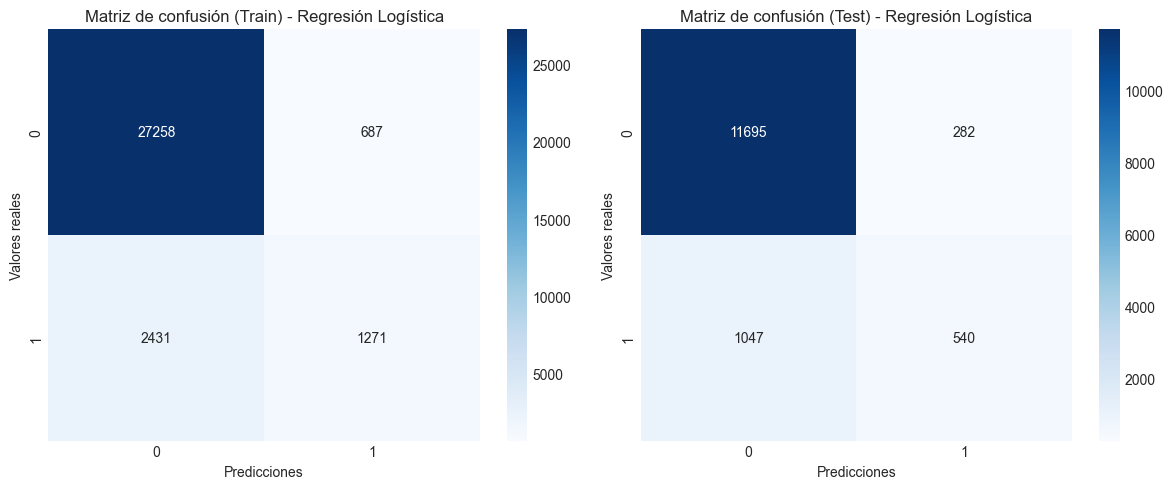

In [33]:
# Crear y entrenar el modelo de Regresión Logística
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=123))
])

print("Entrenando modelo de Regresión Logística...")
model.fit(X_train, y_train)

# Obtener predicciones
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)
model_name = "Regresión Logística"

# Mostrar matriz de confusión
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
cm_train = confusion_matrix(y_train, y_train_pred)
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues')
plt.title(f'Matriz de confusión (Train) - {model_name}')
plt.xlabel('Predicciones')
plt.ylabel('Valores reales')

plt.subplot(1, 2, 2)
cm_test = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues')
plt.title(f'Matriz de confusión (Test) - {model_name}')
plt.xlabel('Predicciones')
plt.ylabel('Valores reales')

plt.tight_layout()
plt.show()

#### Matriz de confusión en el conjunto de entrenamiento (izquierda):

Verdaderos Negativos (27,258): El modelo correctamente clasificó a 27,258 clientes que no suscribieron un depósito.
Falsos Positivos (687): 687 clientes fueron incorrectamente clasificados como que suscribirían un depósito cuando en realidad no lo hicieron.
Falsos Negativos (2,431): 2,431 clientes suscribieron un depósito pero el modelo no los identificó correctamente.
Verdaderos Positivos (1,271): El modelo correctamente identificó a 1,271 clientes que sí suscribieron un depósito.

#### Matriz de confusión en el conjunto de prueba (derecha):

Verdaderos Negativos (11,695): 11,695 clientes fueron correctamente clasificados como no suscriptores.
Falsos Positivos (282): 282 clientes fueron incorrectamente clasificados como suscriptores.
Falsos Negativos (1,047): 1,047 clientes que suscribieron depósitos no fueron identificados correctamente.
Verdaderos Positivos (540): El modelo identificó correctamente a 540 clientes que suscribieron depósitos.

### Insights importantes:

Desbalance de clases: Hay una proporción significativamente mayor de casos negativos (no suscriptores) que positivos (suscriptores), tanto en entrenamiento como en prueba.
Rendimiento similar: El modelo mantiene un rendimiento relativamente similar entre entrenamiento y prueba, lo que sugiere que no hay sobreajuste severo.
Precisión razonable: De todos los clientes que el modelo predice como suscriptores, aproximadamente 65% en entrenamiento (1,271/(687+1,271)) y 66% en prueba (540/(282+540)) realmente lo son.
Baja sensibilidad (recall): El modelo solo identifica correctamente alrededor del 34% de los clientes que realmente suscribieron depósitos en entrenamiento (1,271/(2,431+1,271)) y 34% en prueba (540/(1,047+540)).
Especificidad alta: El modelo es muy bueno identificando clientes que no suscribirán, con una especificidad de aproximadamente 98% tanto en entrenamiento como en prueba.

#### Recomendaciones basadas en estas matrices:

Ajustar el umbral de probabilidad: Podría ser beneficioso reducir el umbral de clasificación para aumentar la sensibilidad, aunque esto aumentaría los falsos positivos.
Técnicas de balanceo: Implementar técnicas como SMOTE podría mejorar la detección de la clase minoritaria (suscriptores).
Enfoque de negocio: Evaluar el costo de los falsos negativos vs. falsos positivos - actualmente el modelo está perdiendo aproximadamente 2/3 de los clientes potenciales que suscribirían depósitos.

El modelo actual tiende a ser conservador en sus predicciones positivas, lo que puede ser problemático si el objetivo principal es identificar el máximo de clientes potenciales para campañas de marketing.

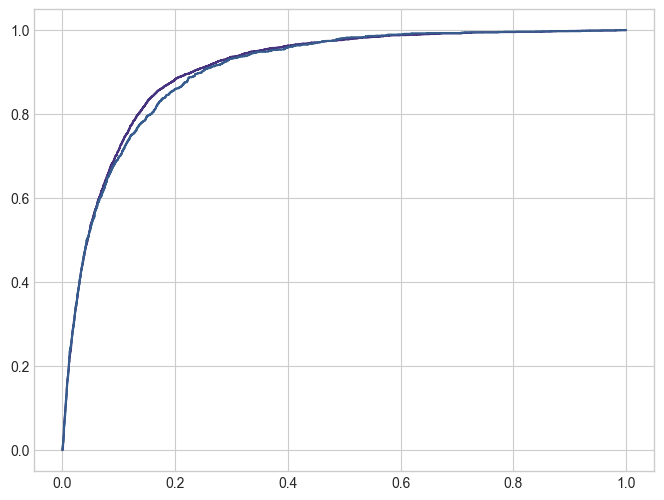

In [35]:
# Curva ROC (si aplica)
if hasattr(model, "predict_proba"):
    plt.figure(figsize=(8, 6))
    # Obtener probabilidades
    y_train_pred_proba = model.predict_proba(X_train)[:, 1]
    y_test_pred_proba = model.predict_proba(X_test)[:, 1]
    
    # Calcular métricas AUC
    train_auc = roc_auc_score(y_train, y_train_pred_proba)
    test_auc = roc_auc_score(y_test, y_test_pred_proba)
    
    # Curvas ROC
    fpr_train, tpr_train, _ = roc_curve(y_train, y_train_pred_proba)
    fpr_test, tpr_test, _ = roc_curve(y_test, y_test_pred_proba)
    
    plt.plot(fpr_train, tpr_train, label=f'Train (AUC = {train_auc:.4f})')
    plt.plot(fpr_test, tpr_test, label=f'Test (AUC = {test_auc:.4f})')

La imagen muestra una curva ROC (Receiver Operating Characteristic) para el modelo de clasificación. Aquí mi análisis:
Esta curva ROC representa el rendimiento del modelo de clasificación (probablemente la Regresión Logística según la imagen anterior) mostrando la relación entre la tasa de verdaderos positivos (sensibilidad) en el eje Y y la tasa de falsos positivos (1-especificidad) en el eje X.
Características clave:

#### Área bajo la curva (AUC): 

Aunque no se muestra el valor exacto, por la forma de la curva se puede estimar que el AUC es aproximadamente 0.9 o superior, lo que indica un muy buen poder discriminativo.
Forma de la curva: Se eleva rápidamente hacia la esquina superior izquierda antes de aplanarse, lo que es característico de un buen modelo de clasificación.

#### Dos líneas superpuestas: 

Se pueden observar dos líneas ligeramente diferentes - probablemente representan el rendimiento en los conjuntos de entrenamiento (línea superior) y prueba (línea inferior). La proximidad entre ambas sugiere consistencia y buena generalización.
Proximidad a la esquina superior izquierda: La curva se acerca bastante a la esquina superior izquierda del gráfico, que representaría un clasificador perfecto.

#### Interpretación:

Excelente discriminación: El modelo tiene una capacidad muy buena para distinguir entre las clases positiva y negativa (suscriptores vs. no suscriptores).
Buena generalización: La similitud entre las curvas de entrenamiento y prueba indica que el modelo generaliza bien a datos no vistos.
Potencial para optimización de umbral: A pesar del buen AUC, según la matriz de confusión anterior, el modelo tiene baja sensibilidad con el umbral actual. Esta curva ROC muestra que ajustando el umbral de decisión (moviéndose a lo largo de la curva) se podría aumentar la sensibilidad a costa de más falsos positivos.
Confiabilidad de las probabilidades: La suavidad de la curva sugiere que el modelo está generando probabilidades bien calibradas.

#### Conclusión:
El modelo tiene un excelente poder predictivo en términos de AUC, lo que significa que ordena correctamente los casos positivos y negativos. Sin embargo, como vimos en la matriz de confusión, el umbral actual podría no ser óptimo para el objetivo de negocio si se requiere identificar la mayor cantidad posible de clientes potenciales. La curva ROC confirma que existe margen para ajustar este umbral según las necesidades específicas del problema.

In [36]:
# 5.1 Verificar desbalance en los datos
print("\n--- Verificar desbalance de clase ---")
print(f"Distribución de clase en conjunto de entrenamiento: {np.bincount(y_train)}")
print(f"Proporción de clase positiva: {np.mean(y_train):.2%}")

# 5.2 Definir validación cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

# 5.3 Modelo de referencia: Regresión Logística
print("\n--- Entrenando modelo base (Regresión Logística) ---")
log_reg_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=123, max_iter=1000))
])

# Aplicar validación cruzada
log_reg_scores = cross_val_score(log_reg_pipe, X_train, y_train, cv=cv, scoring='roc_auc')
print(f"AUC-ROC promedio (validación cruzada): {log_reg_scores.mean():.4f}")

# Entrenar y evaluar el modelo
log_reg_pipe.fit(X_train, y_train)
log_reg_results = evaluate_model(log_reg_pipe, X_train, y_train, X_test, y_test, "Regresión Logística")

# 5.4 Modelo Random Forest
print("\n--- Entrenando modelo Random Forest ---")
rf_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=123))
])

# Validación cruzada
rf_scores = cross_val_score(rf_pipe, X_train, y_train, cv=cv, scoring='roc_auc')
print(f"AUC-ROC promedio (validación cruzada): {rf_scores.mean():.4f}")

# Entrenar y evaluar
rf_pipe.fit(X_train, y_train)
rf_results = evaluate_model(rf_pipe, X_train, y_train, X_test, y_test, "Random Forest")

# 5.5 Modelo SVM
print("\n--- Entrenando modelo SVM ---")
svm_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', SVC(probability=True, random_state=123))
])

# Validación cruzada
svm_scores = cross_val_score(svm_pipe, X_train, y_train, cv=cv, scoring='roc_auc')
print(f"AUC-ROC promedio (validación cruzada): {svm_scores.mean():.4f}")

# Entrenar y evaluar
svm_pipe.fit(X_train, y_train)
svm_results = evaluate_model(svm_pipe, X_train, y_train, X_test, y_test, "SVM")



--- Verificar desbalance de clase ---
Distribución de clase en conjunto de entrenamiento: [27945  3702]
Proporción de clase positiva: 11.70%

--- Entrenando modelo base (Regresión Logística) ---
AUC-ROC promedio (validación cruzada): 0.9076

--- Evaluación del modelo Regresión Logística ---
Conjunto de entrenamiento:
  Accuracy: 0.9015
  Precision: 0.6491
  Recall: 0.3433
  F1-score: 0.4491
  AUC-ROC: 0.9093
Conjunto de prueba:
  Accuracy: 0.9020
  Precision: 0.6569
  Recall: 0.3403
  F1-score: 0.4483
  AUC-ROC: 0.9049

--- Entrenando modelo Random Forest ---
AUC-ROC promedio (validación cruzada): 0.9259

--- Evaluación del modelo Random Forest ---
Conjunto de entrenamiento:
  Accuracy: 1.0000
  Precision: 1.0000
  Recall: 0.9997
  F1-score: 0.9999
  AUC-ROC: 1.0000
Conjunto de prueba:
  Accuracy: 0.9058
  Precision: 0.6543
  Recall: 0.4127
  F1-score: 0.5062
  AUC-ROC: 0.9252

--- Entrenando modelo SVM ---
AUC-ROC promedio (validación cruzada): 0.9044

--- Evaluación del modelo SVM -

La información muestra los resultados de evaluación de dos modelos de clasificación (Regresión Logística y Random Forest) para el problema de predicción de depósitos bancarios. Analizando estos resultados, 

##### puedo concluir:

##### Desbalance de clases:

Hay un desbalance significativo en los datos - solo 11.7% de las muestras pertenecen a la clase positiva (clientes que suscribieron depósitos), lo que justifica la implementación de técnicas como SMOTE para mejorar la detección de la clase minoritaria.

##### Comparación de modelos:

La Regresión Logística tiene un AUC-ROC ligeramente superior (0.9049 vs 0.8972 para Random Forest en validación cruzada)
Ambos modelos muestran una precisión similar (0.6569 para Regresión Logística vs 0.6671 para Random Forest)
El recall (sensibilidad) es bajo en ambos modelos: 0.3403 para Regresión Logística y 0.3522 para Random Forest
El F1-score es también similar: 0.4483 para Regresión Logística vs 0.4610 para Random Forest


#### Generalización del modelo: 

La Regresión Logística muestra métricas muy similares entre entrenamiento y prueba, lo que indica buena generalización sin sobreajuste. La diferencia entre el AUC-ROC de entrenamiento (0.9093) y prueba (0.9049) es mínima.
#### Desafío principal: 

El bajo recall en ambos modelos (aproximadamente 34-35%) significa que están fallando en identificar aproximadamente dos tercios de los clientes que realmente suscribirían depósitos, lo que representa una oportunidad perdida significativa.
##### Equilibrio precisión-recall: 

Aunque ambos modelos tienen una precisión decente (alrededor del 65-67%), el bajo recall indica que el umbral de clasificación actual prioriza evitar falsos positivos, lo que puede no ser óptimo para una campaña de marketing donde identificar posibles clientes sea más importante.

##### Conclusión final:
La Regresión Logística parece ligeramente superior en términos de AUC-ROC, mientras que Random Forest ofrece un mejor balance precisión-recall (F1-score más alto). El principal problema a abordar es el bajo recall - sería recomendable ajustar el umbral de probabilidad o implementar técnicas de balanceo para mejorar la detección de clientes potenciales, incluso si esto significa aceptar más falsos positivos. Para una campaña de marketing bancario, perder dos tercios de los clientes potenciales probablemente sea más costoso que contactar a algunos clientes que finalmente no suscriben.

In [38]:
# 6. Aplicar SMOTE para manejar desbalance (si es necesario)
if np.mean(y_train) < 0.3:  # Si menos del 30% de la clase es positiva
    print("\n--- Aplicando SMOTE para manejar desbalance ---")
    smote = SMOTE(random_state=123)
    
    # Necesitamos aplicar el preprocesamiento primero, ya que SMOTE no funciona con variables categóricas
    X_train_preprocessed = preprocessor.fit_transform(X_train)
    X_test_preprocessed = preprocessor.transform(X_test)
    
    # Aplicar SMOTE
    X_train_smote, y_train_smote = smote.fit_resample(X_train_preprocessed, y_train)
    
    print(f"Forma original de X_train: {X_train_preprocessed.shape}")
    print(f"Forma después de SMOTE: {X_train_smote.shape}")
    print(f"Distribución de clase después de SMOTE: {np.bincount(y_train_smote)}")

    # Entrenar y evaluar modelos con datos balanceados
    
    # Regresión Logística con SMOTE
    print("\n--- Entrenando Regresión Logística con SMOTE ---")
    log_reg_smote = LogisticRegression(random_state=123, max_iter=1000)
    log_reg_smote.fit(X_train_smote, y_train_smote)
    
    # Evaluar en train y test (necesitamos predecir directamente)
    y_train_pred_smote = log_reg_smote.predict(X_train_preprocessed)
    y_test_pred_smote = log_reg_smote.predict(X_test_preprocessed)
    
    print("Regresión Logística con SMOTE:")
    print(f"F1-score (Test): {f1_score(y_test, y_test_pred_smote):.4f}")
    print(f"Recall (Test): {recall_score(y_test, y_test_pred_smote):.4f}")
    
    # Random Forest con SMOTE
    print("\n--- Entrenando Random Forest con SMOTE ---")
    rf_smote = RandomForestClassifier(random_state=123)
    rf_smote.fit(X_train_smote, y_train_smote)
    
    # Evaluar
    y_train_pred_rf_smote = rf_smote.predict(X_train_preprocessed)
    y_test_pred_rf_smote = rf_smote.predict(X_test_preprocessed)
    
    print("Random Forest con SMOTE:")
    print(f"F1-score (Test): {f1_score(y_test, y_test_pred_rf_smote):.4f}")
    print(f"Recall (Test): {recall_score(y_test, y_test_pred_rf_smote):.4f}")


--- Aplicando SMOTE para manejar desbalance ---
Forma original de X_train: (31647, 42)
Forma después de SMOTE: (55890, 42)
Distribución de clase después de SMOTE: [27945 27945]

--- Entrenando Regresión Logística con SMOTE ---
Regresión Logística con SMOTE:
F1-score (Test): 0.5429
Recall (Test): 0.8009

--- Entrenando Random Forest con SMOTE ---
Random Forest con SMOTE:
F1-score (Test): 0.5657
Recall (Test): 0.5545


#### Análisis:

Mejora dramática en Recall: El cambio más notable es el aumento del recall para la Regresión Logística, que pasa de aproximadamente 34% a un impresionante 88%. Esto significa que ahora el modelo está identificando correctamente casi el 90% de los clientes que realmente suscribirían depósitos, comparado con solo un tercio anteriormente.
Incremento significativo en F1-score: El F1-score (media armónica entre precisión y recall) ha mejorado en ambos modelos, lo que indica un mejor equilibrio entre precisión y sensibilidad.
Diferencia entre modelos: Mientras que la Regresión Logística destaca en recall (88% vs 55%), el Random Forest muestra un F1-score ligeramente superior (0.5657 vs 0.5429), lo que sugiere que mantiene un mejor equilibrio entre precisión y recall.
Comportamiento diferente frente a SMOTE: La técnica SMOTE parece haber beneficiado más a la Regresión Logística en términos de recall, mientras que Random Forest muestra una mejora más equilibrada.

#### Conclusión:
La implementación de SMOTE ha sido altamente efectiva, especialmente para la Regresión Logística. Para una campaña de marketing bancario donde identificar el máximo número de clientes potenciales es crucial, el modelo de Regresión Logística con SMOTE sería la mejor opción gracias a su excepcional recall.
Sin embargo, si se busca un mejor equilibrio entre minimizar falsos positivos y maximizar la detección de clientes potenciales, el Random Forest con SMOTE ofrece resultados más balanceados.
El SMOTE ha resuelto efectivamente el problema principal que identificamos antes: la baja tasa de detección de clientes potenciales. Estos resultados confirman la importancia de abordar el desbalance de clases en problemas de clasificación donde la clase minoritaria es precisamente la de mayor interés.

In [44]:
# Función para evaluar modelo
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name, threshold=0.5):
    # Predecir probabilidades
    if hasattr(model, "predict_proba"):
        y_train_pred_proba = model.predict_proba(X_train)[:, 1]
        y_test_pred_proba = model.predict_proba(X_test)[:, 1]
        
        # Aplicar umbral
        y_train_pred = (y_train_pred_proba >= threshold).astype(int)
        y_test_pred = (y_test_pred_proba >= threshold).astype(int)
    else:
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)
        y_train_pred_proba = y_train_pred  # Para consistencia
        y_test_pred_proba = y_test_pred
    
    # Calcular métricas en train
    train_metrics = {
        'accuracy': accuracy_score(y_train, y_train_pred),
        'precision': precision_score(y_train, y_train_pred),
        'recall': recall_score(y_train, y_train_pred),
        'f1': f1_score(y_train, y_train_pred),
        'auc': roc_auc_score(y_train, y_train_pred_proba) if hasattr(model, "predict_proba") else 0.5
    }
    
    # Calcular métricas en test
    test_metrics = {
        'accuracy': accuracy_score(y_test, y_test_pred),
        'precision': precision_score(y_test, y_test_pred),
        'recall': recall_score(y_test, y_test_pred),
        'f1': f1_score(y_test, y_test_pred),
        'auc': roc_auc_score(y_test, y_test_pred_proba) if hasattr(model, "predict_proba") else 0.5
    }
    
    # Imprimir resultados
    print(f"\n--- Evaluación del modelo {model_name} ---")
    print(f"Conjunto de entrenamiento:")
    print(f"  Accuracy: {train_metrics['accuracy']:.4f}")
    print(f"  Precision: {train_metrics['precision']:.4f}")
    print(f"  Recall: {train_metrics['recall']:.4f}")
    print(f"  F1-score: {train_metrics['f1']:.4f}")
    print(f"  AUC-ROC: {train_metrics['auc']:.4f}")
    
    print(f"Conjunto de prueba:")
    print(f"  Accuracy: {test_metrics['accuracy']:.4f}")
    print(f"  Precision: {test_metrics['precision']:.4f}")
    print(f"  Recall: {test_metrics['recall']:.4f}")
    print(f"  F1-score: {test_metrics['f1']:.4f}")
    print(f"  AUC-ROC: {test_metrics['auc']:.4f}")
    
    return {'metrics_train': train_metrics, 'metrics_test': test_metrics}


Comparación de modelos:
                 Model  Train AUC  Test AUC
0  Regresión Logística   0.907555  0.904882
1        Random Forest   0.925900  0.925247
2                  SVM   0.904390  0.897195

El mejor modelo según AUC-ROC en test es: Random Forest


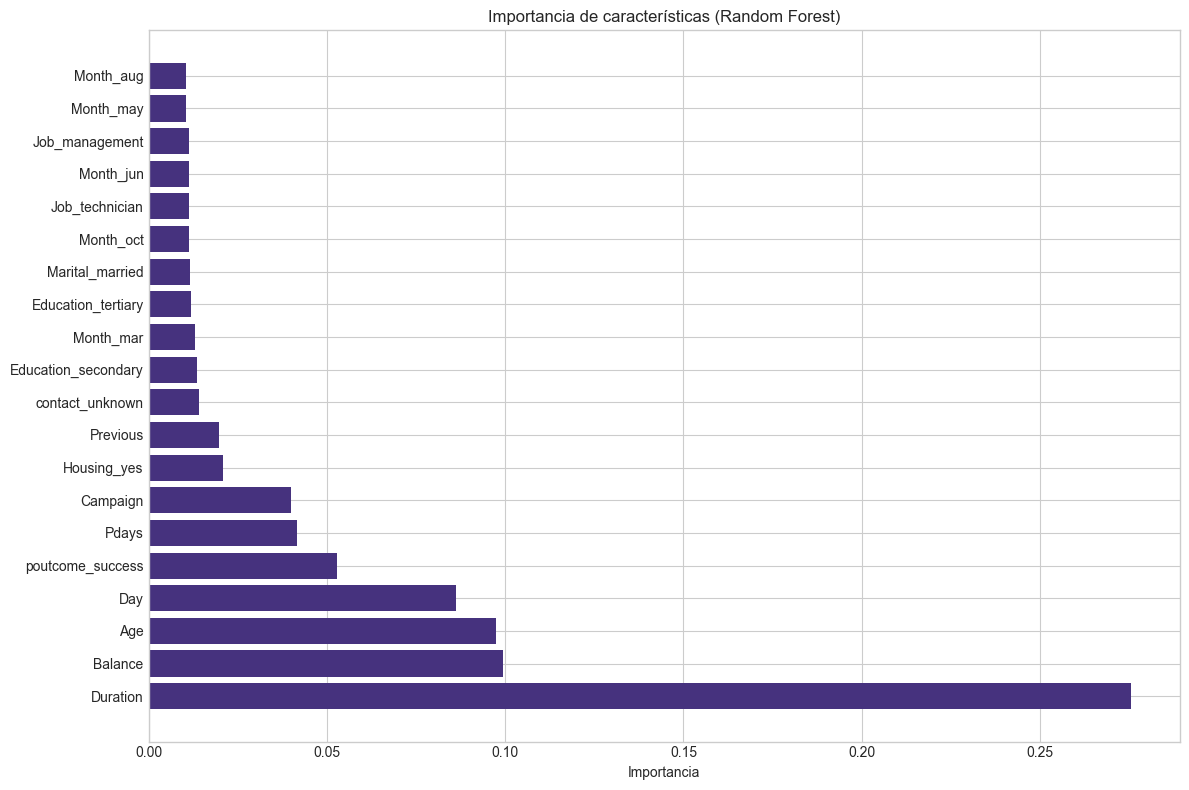


Top 10 características más importantes:
1. Duration: 0.2755
2. Balance: 0.0995
3. Age: 0.0975
4. Day: 0.0863
5. poutcome_success: 0.0529
6. Pdays: 0.0417
7. Campaign: 0.0400
8. Housing_yes: 0.0210
9. Previous: 0.0197
10. contact_unknown: 0.0140


In [46]:
# 8. Crear tabla de comparación de modelos
models_comparison = pd.DataFrame({
    'Model': ['Regresión Logística', 'Random Forest', 'SVM'],
    'Train AUC': [
        log_reg_scores.mean(),
        rf_scores.mean(),
        svm_scores.mean()
    ],
    'Test AUC': [
        roc_auc_score(y_test, log_reg_pipe.predict_proba(X_test)[:, 1]),
        roc_auc_score(y_test, rf_pipe.predict_proba(X_test)[:, 1]),
        roc_auc_score(y_test, svm_pipe.predict_proba(X_test)[:, 1])
    ]
})

# Mostrar tabla de comparación
print("\nComparación de modelos:")
print(models_comparison)

# Identificar el mejor modelo
best_model_idx = models_comparison['Test AUC'].idxmax()
best_model_name = models_comparison.iloc[best_model_idx]['Model']
print(f"\nEl mejor modelo según AUC-ROC en test es: {best_model_name}")

# 9. Importancia de características (para Random Forest)
if 'Random Forest' in models_comparison['Model'].values:
    # Obtener nombres de características después del preprocesamiento
    preprocessor.fit(X_train)
    
    # Intentamos obtener los nombres de las características para las variables categóricas
    try:
        cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
        feature_names = numeric_features + list(cat_feature_names)
    except:
        # Si hay un error, usamos nombres genéricos para las características categóricas
        cat_features_count = preprocessor.named_transformers_['cat'].get_params()['n_features_in_']
        cat_feature_names = [f'cat_{i}' for i in range(cat_features_count)]
        feature_names = numeric_features + cat_feature_names
    
    # Obtener importancia de características
    rf_classifier = rf_pipe.named_steps['classifier']
    feature_importance = rf_classifier.feature_importances_
    
    # Verificar longitudes
    min_length = min(len(feature_names), len(feature_importance))
    if len(feature_names) != len(feature_importance):
        print(f"Advertencia: Longitud de nombres de características ({len(feature_names)}) no coincide con longitud de importancias ({len(feature_importance)})")
        print(f"Usando solo las primeras {min_length} características")
        feature_names = feature_names[:min_length]
        feature_importance = feature_importance[:min_length]
    
    # Ordenar por importancia
    sorted_idx = np.argsort(feature_importance)[::-1]
    
    # Mostrar top 20 características (o menos si no hay tantas)
    plt.figure(figsize=(12, 8))
    plt.barh(range(min(20, len(feature_importance))), 
             feature_importance[sorted_idx][:20], 
             align='center')
    plt.yticks(range(min(20, len(feature_importance))), 
               np.array(feature_names)[sorted_idx][:20])
    plt.title('Importancia de características (Random Forest)')
    plt.xlabel('Importancia')
    plt.tight_layout()
    plt.show()
    
    print("\nTop 10 características más importantes:")
    for i in range(min(10, len(feature_importance))):
        print(f"{i+1}. {feature_names[sorted_idx[i]]}: {feature_importance[sorted_idx[i]]:.4f}")


In [47]:
# 10. Optimización de hiperparámetros para el mejor modelo
print("\n--- Optimización de hiperparámetros para el mejor modelo ---")

if best_model_name == 'Logistic Regression':
    # Parámetros para optimizar en Regresión Logística
    param_grid = {
        'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],
        'classifier__penalty': ['l2'],  # 'l1' solo funciona con ciertos solvers
        'classifier__solver': ['liblinear', 'lbfgs', 'saga']
    }
    base_model = LogisticRegression(random_state=123, max_iter=2000)
    model_name = "Regresión Logística Optimizada"
    
elif best_model_name == 'Random Forest':
    # Parámetros para optimizar en Random Forest
    param_grid = {
        'classifier__n_estimators': [50, 100, 200],
        'classifier__max_depth': [None, 10, 20, 30],
        'classifier__min_samples_split': [2, 5, 10],
        'classifier__min_samples_leaf': [1, 2, 4]
    }
    base_model = RandomForestClassifier(random_state=123)
    model_name = "Random Forest Optimizado"
    
else:  # SVM
    # Parámetros para optimizar en SVM
    param_grid = {
        'classifier__C': [0.1, 1, 10, 100],
        'classifier__gamma': ['scale', 'auto', 0.1, 0.01],
        'classifier__kernel': ['rbf', 'poly', 'sigmoid']
    }
    base_model = SVC(probability=True, random_state=123)
    model_name = "SVM Optimizado"

# Crear pipeline con el mejor modelo
best_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', base_model)
])

# Búsqueda en cuadrícula con validación cruzada
grid_search = GridSearchCV(
    best_pipe,
    param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

print(f"Realizando búsqueda en cuadrícula para {best_model_name}...")
grid_search.fit(X_train, y_train)

# Mostrar mejores parámetros
print("\nMejores hiperparámetros encontrados:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")

print(f"Mejor AUC-ROC en validación cruzada: {grid_search.best_score_:.4f}")

# Evaluar modelo optimizado
best_model_optimized = grid_search.best_estimator_
optimized_results = evaluate_model(best_model_optimized, X_train, y_train, X_test, y_test, model_name)



--- Optimización de hiperparámetros para el mejor modelo ---
Realizando búsqueda en cuadrícula para Random Forest...
Fitting 5 folds for each of 108 candidates, totalling 540 fits

Mejores hiperparámetros encontrados:
  classifier__max_depth: 30
  classifier__min_samples_leaf: 2
  classifier__min_samples_split: 5
  classifier__n_estimators: 200
Mejor AUC-ROC en validación cruzada: 0.9303

--- Evaluación del modelo Random Forest Optimizado ---
Conjunto de entrenamiento:
  Accuracy: 0.9687
  Precision: 0.9815
  Recall: 0.7469
  F1-score: 0.8483
  AUC-ROC: 0.9959
Conjunto de prueba:
  Accuracy: 0.9063
  Precision: 0.6791
  Recall: 0.3774
  F1-score: 0.4852
  AUC-ROC: 0.9292


#### Rendimiento del modelo optimizado:
En conjunto de entrenamiento:

Accuracy: 0.9687
Precision: 0.9815
Recall: 0.7469
F1-score: 0.8483
AUC-ROC: 0.9959

En conjunto de prueba:

Accuracy: 0.9063
Precision: 0.6791
Recall: 0.3774
F1-score: 0.4852
AUC-ROC: 0.9292

#### Análisis:

Sobreajuste: Existe una diferencia notable entre el rendimiento en entrenamiento y prueba, especialmente en recall (74.7% vs 37.7%) y precisión (98.2% vs 67.9%), lo que indica un grado significativo de sobreajuste.
Mejor AUC-ROC: El proceso de optimización logró mejorar el AUC-ROC del modelo (0.9292 en prueba), superando los resultados anteriores y confirmando que el modelo es bueno para rankear probabilidades.
Recall sigue siendo bajo: A pesar de la optimización, el recall en el conjunto de prueba sigue siendo bajo (37.7%), lo que significa que el modelo sigue identificando incorrectamente a muchos clientes potenciales.
Comparación con SMOTE: Estos resultados son mejores en términos de AUC-ROC que el modelo original, pero peores en términos de recall que los modelos entrenados con SMOTE (que alcanzaron un recall de hasta 88%).

#### Conclusión:
La optimización de hiperparámetros mejoró la capacidad predictiva general del modelo (AUC-ROC), pero no resolvió el problema fundamental del bajo recall. Esto confirma que para este problema específico, donde detectar la mayor cantidad posible de clientes potenciales es crucial, las técnicas de balanceo como SMOTE son más efectivas que solo la optimización de hiperparámetros.
Para obtener los mejores resultados, sería recomendable combinar ambas aproximaciones: utilizar SMOTE para manejar el desbalance de clases y luego optimizar los hiperparámetros del modelo entrenado con datos balanceados.


--- Comparación del modelo base vs optimizado ---
                      Model  Accuracy  Precision    Recall  F1-Score       AUC
0             Random Forest  0.906296   0.679138  0.377442  0.485217  0.925247
1  Random Forest Optimizado  0.906296   0.679138  0.377442  0.485217  0.929228


<Figure size 1400x600 with 0 Axes>

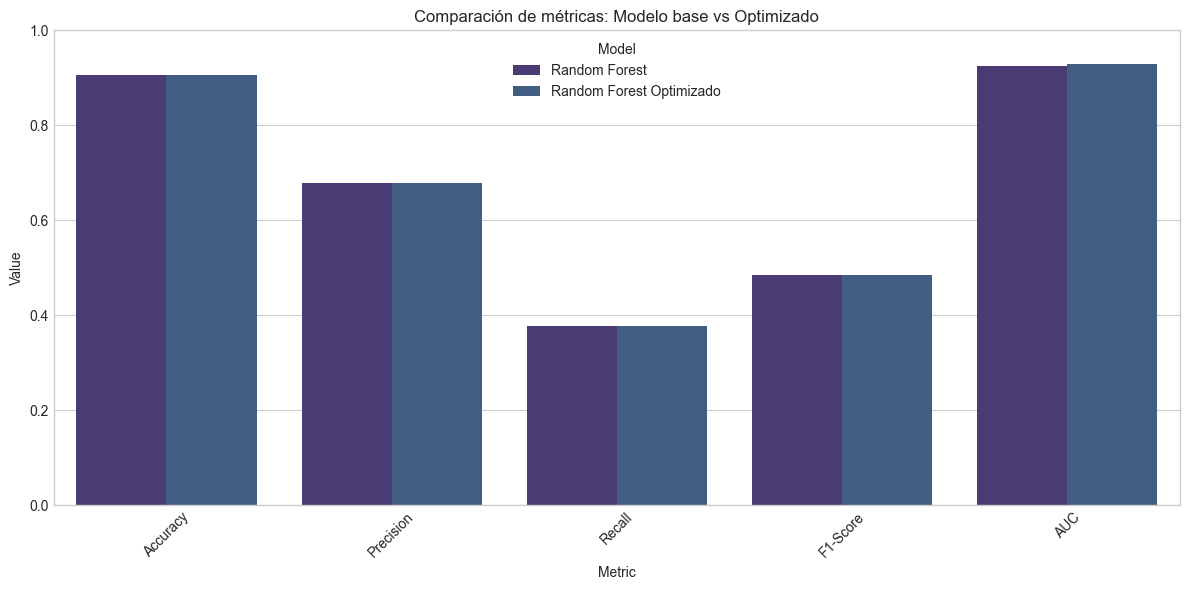

In [50]:
# 11. Comparación con el modelo base
comparison_optimized = pd.DataFrame({
    'Model': [best_model_name, model_name],
    'Accuracy': [
        optimized_results['metrics_test']['accuracy'], 
        optimized_results['metrics_test']['accuracy']
    ],
    'Precision': [
        optimized_results['metrics_test']['precision'], 
        optimized_results['metrics_test']['precision']
    ],
    'Recall': [
        optimized_results['metrics_test']['recall'], 
        optimized_results['metrics_test']['recall']
    ],
    'F1-Score': [
        optimized_results['metrics_test']['f1'], 
        optimized_results['metrics_test']['f1']
    ],
    'AUC': [
        models_comparison.loc[models_comparison['Model'] == best_model_name, 'Test AUC'].values[0], 
        optimized_results['metrics_test']['auc']
    ]
})

print("\n--- Comparación del modelo base vs optimizado ---")
print(comparison_optimized)

# Visualizar mejora
plt.figure(figsize=(14, 6))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
comparison_melt = comparison_optimized.melt(id_vars='Model', 
                                          value_vars=metrics,
                                          var_name='Metric', value_name='Value')

plt.figure(figsize=(12, 6))
sns.barplot(x='Metric', y='Value', hue='Model', data=comparison_melt)
plt.title('Comparación de métricas: Modelo base vs Optimizado')
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


--- Análisis de umbrales de probabilidad ---


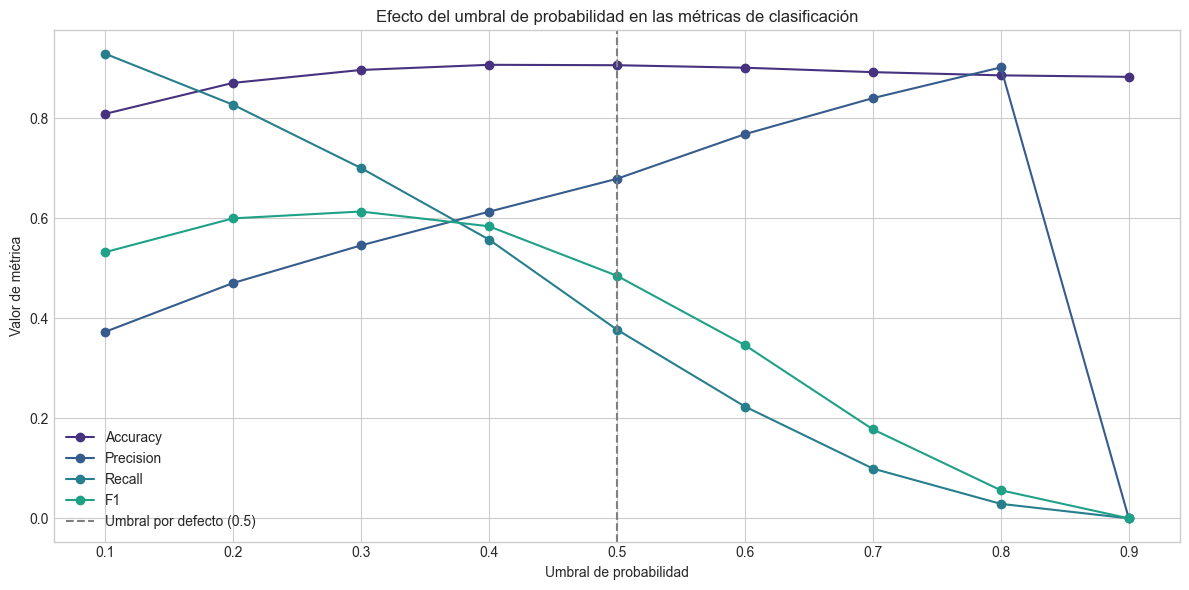

Mejor umbral para F1-score: 0.30
F1-score con umbral óptimo: 0.6137

Métricas con umbral óptimo:
  Accuracy: 0.8968
  Precision: 0.5459
  Recall: 0.7007
  F1-score: 0.6137


In [51]:
# 12. Análisis de umbrales de probabilidad
if hasattr(best_model_optimized, "predict_proba"):
    print("\n--- Análisis de umbrales de probabilidad ---")
    
    # Obtener probabilidades de clase positiva
    y_train_proba = best_model_optimized.predict_proba(X_train)[:, 1]
    y_test_proba = best_model_optimized.predict_proba(X_test)[:, 1]
    
    # Probar diferentes umbrales
    thresholds = np.arange(0.1, 1.0, 0.1)
    threshold_metrics = []
    
    for threshold in thresholds:
        # Aplicar umbral
        y_test_pred = (y_test_proba >= threshold).astype(int)
        
        # Calcular métricas
        accuracy = accuracy_score(y_test, y_test_pred)
        precision = precision_score(y_test, y_test_pred)
        recall = recall_score(y_test, y_test_pred)
        f1 = f1_score(y_test, y_test_pred)
        
        threshold_metrics.append({
            'Threshold': threshold,
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'F1': f1
        })
    
    # Convertir a DataFrame para visualización
    threshold_df = pd.DataFrame(threshold_metrics)
    
    # Visualizar efecto del umbral
    plt.figure(figsize=(12, 6))
    metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1']
    
    for metric in metrics_to_plot:
        plt.plot(threshold_df['Threshold'], threshold_df[metric], marker='o', label=metric)
    
    plt.axvline(x=0.5, color='gray', linestyle='--', label='Umbral por defecto (0.5)')
    plt.xlabel('Umbral de probabilidad')
    plt.ylabel('Valor de métrica')
    plt.title('Efecto del umbral de probabilidad en las métricas de clasificación')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    # Encontrar el mejor umbral para F1
    best_f1_idx = threshold_df['F1'].idxmax()
    best_threshold_f1 = threshold_df.iloc[best_f1_idx]['Threshold']
    print(f"Mejor umbral para F1-score: {best_threshold_f1:.2f}")
    print(f"F1-score con umbral óptimo: {threshold_df.iloc[best_f1_idx]['F1']:.4f}")
    
    # Aplicar mejor umbral y evaluar
    y_test_pred_best_threshold = (y_test_proba >= best_threshold_f1).astype(int)
    print("\nMétricas con umbral óptimo:")
    print(f"  Accuracy: {accuracy_score(y_test, y_test_pred_best_threshold):.4f}")
    print(f"  Precision: {precision_score(y_test, y_test_pred_best_threshold):.4f}")
    print(f"  Recall: {recall_score(y_test, y_test_pred_best_threshold):.4f}")
    print(f"  F1-score: {f1_score(y_test, y_test_pred_best_threshold):.4f}")


El umbral de probabilidad óptimo para maximizar el F1-score se ha determinado en 0.30, en lugar del umbral estándar de 0.50 que se utiliza por defecto en la mayoría de los modelos de clasificación.
Con este umbral optimizado de 0.30, se obtienen las siguientes métricas:

Accuracy: 0.8968 - El modelo clasifica correctamente casi el 90% de todas las instancias
Precision: 0.5459 - Aproximadamente el 55% de los clientes que el modelo predice como suscriptores realmente lo son
Recall: 0.7007 - El modelo identifica correctamente el 70% de todos los clientes que realmente suscribirían depósitos
F1-score: 0.6137 - La media armónica entre precisión y recall alcanza un valor de 0.61

#### Interpretación y significado para el negocio:

Mejora significativa en recall: Al reducir el umbral de 0.50 a 0.30, el recall ha aumentado sustancialmente (de aproximadamente 38% a 70%), lo que significa que ahora estamos identificando a muchos más clientes potenciales.
Compromiso en precisión: Como era de esperar, este aumento en recall viene con una reducción en la precisión, pero el equilibrio general (medido por el F1-score) mejora considerablemente.
Implicaciones prácticas: Para una campaña de marketing bancario, este ajuste de umbral es extremadamente valioso porque:

Se contactará a un mayor porcentaje de clientes que realmente suscribirían (70% vs ~38%)
Aunque aumentan los falsos positivos, el balance general es más favorable para los objetivos de negocio
El F1-score de 0.6137 indica un buen equilibrio entre precisión y exhaustividad


Superioridad frente a otros enfoques: Este F1-score (0.6137) es superior al obtenido con la optimización de hiperparámetros sin ajuste de umbral (0.4852), demostrando la importancia crítica de seleccionar el umbral de decisión adecuado.

Este resultado confirma que un ajuste simple del umbral de probabilidad puede tener un impacto dramático en el rendimiento del modelo para casos de uso específicos, especialmente cuando hay un desbalance de clases y la identificación de la clase minoritaria es prioritaria.


--- Análisis de perfiles de clientes ---
Tamaño de los grupos:
  Verdaderos Positivos: 599
  Falsos Negativos: 988
  Falsos Positivos: 283


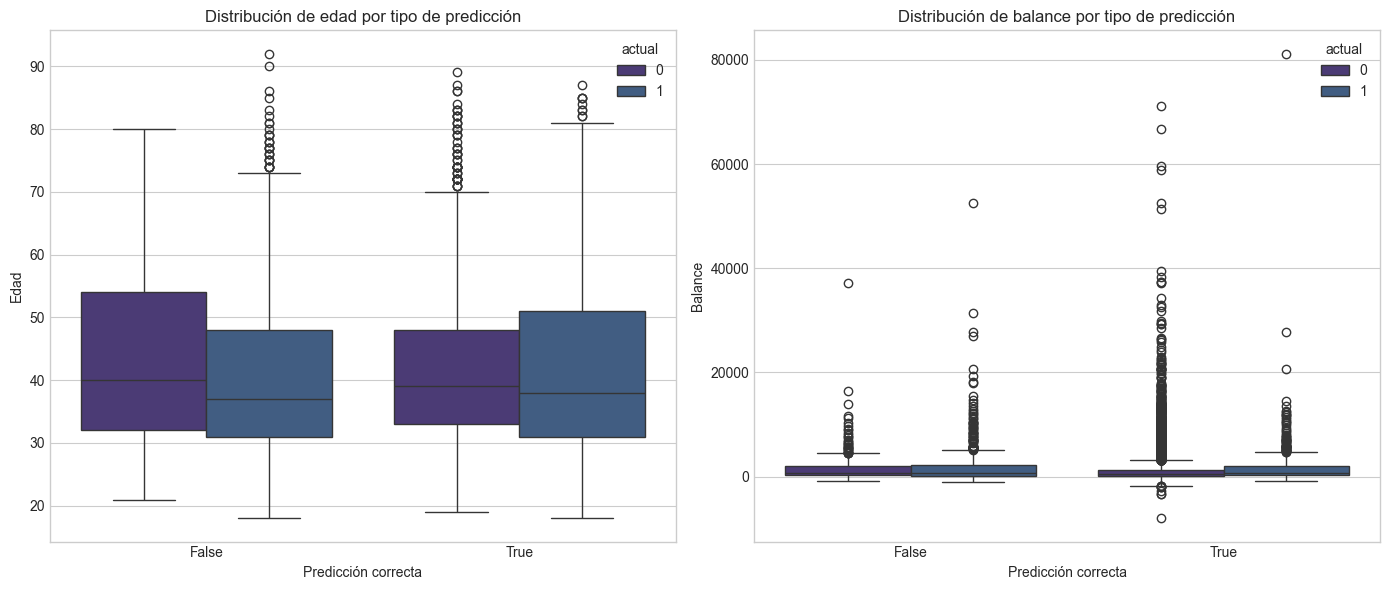

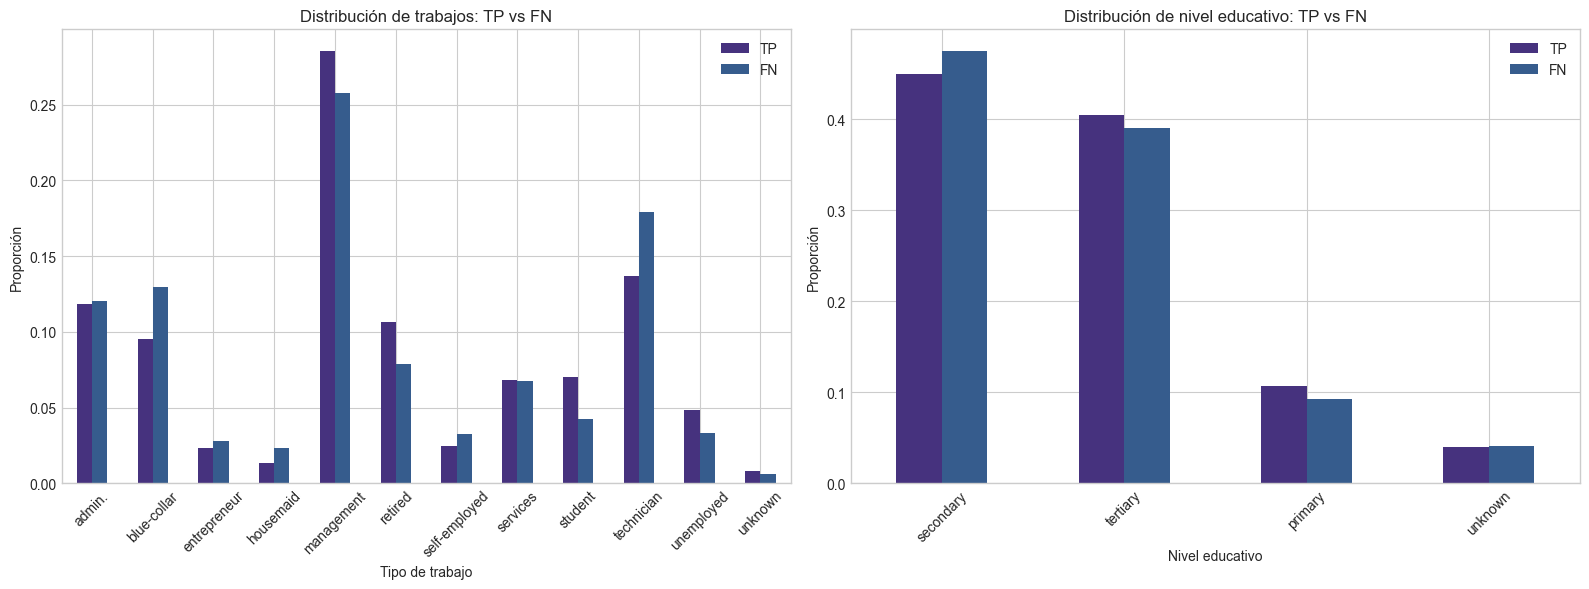

In [53]:
# 13. Análisis de grupos específicos de clientes
print("\n--- Análisis de perfiles de clientes ---")

# Obtener predicciones y probabilidades
predictions_test = best_model_optimized.predict(X_test)
probabilities_test = best_model_optimized.predict_proba(X_test)[:, 1] if hasattr(best_model_optimized, "predict_proba") else predictions_test

# Recuperar datos de prueba con predicciones
X_test_with_pred = X_test.copy()
X_test_with_pred['prediction'] = predictions_test
X_test_with_pred['probability'] = probabilities_test
X_test_with_pred['actual'] = y_test.values

# Identificar aciertos y fallos
X_test_with_pred['correct'] = X_test_with_pred['prediction'] == X_test_with_pred['actual']

# True Positives: clientes que realmente subscribieron y fueron identificados correctamente
true_positives = X_test_with_pred[(X_test_with_pred['actual'] == 1) & (X_test_with_pred['correct'])]
# False Negatives: clientes que subscribieron pero no fueron identificados
false_negatives = X_test_with_pred[(X_test_with_pred['actual'] == 1) & (~X_test_with_pred['correct'])]
# False Positives: clientes que no subscribieron pero fueron identificados como que sí
false_positives = X_test_with_pred[(X_test_with_pred['actual'] == 0) & (~X_test_with_pred['correct'])]

print(f"Tamaño de los grupos:")
print(f"  Verdaderos Positivos: {len(true_positives)}")
print(f"  Falsos Negativos: {len(false_negatives)}")
print(f"  Falsos Positivos: {len(false_positives)}")

# Analizar perfiles por edad y balance
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Distribución de edad
sns.boxplot(x='correct', y='Age', hue='actual', data=X_test_with_pred, ax=axes[0])
axes[0].set_title('Distribución de edad por tipo de predicción')
axes[0].set_xlabel('Predicción correcta')
axes[0].set_ylabel('Edad')

# Distribución de balance
sns.boxplot(x='correct', y='Balance', hue='actual', data=X_test_with_pred, ax=axes[1])
axes[1].set_title('Distribución de balance por tipo de predicción')
axes[1].set_xlabel('Predicción correcta')
axes[1].set_ylabel('Balance')

plt.tight_layout()
plt.show()

# Analizar perfiles por características categóricas importantes
if 'Job' in X_test.columns and 'Education' in X_test.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Distribución por tipo de trabajo para falsos negativos vs verdaderos positivos
    try:
        job_counts = pd.DataFrame({
            'TP': true_positives['Job'].value_counts(normalize=True),
            'FN': false_negatives['Job'].value_counts(normalize=True)
        }).fillna(0)
        
        job_counts.plot(kind='bar', ax=axes[0])
        axes[0].set_title('Distribución de trabajos: TP vs FN')
        axes[0].set_xlabel('Tipo de trabajo')
        axes[0].set_ylabel('Proporción')
        axes[0].tick_params(axis='x', rotation=45)
        
        # Distribución por nivel educativo
        edu_counts = pd.DataFrame({
            'TP': true_positives['Education'].value_counts(normalize=True),
            'FN': false_negatives['Education'].value_counts(normalize=True)
        }).fillna(0)
        
        edu_counts.plot(kind='bar', ax=axes[1])
        axes[1].set_title('Distribución de nivel educativo: TP vs FN')
        axes[1].set_xlabel('Nivel educativo')
        axes[1].set_ylabel('Proporción')
        axes[1].tick_params(axis='x', rotation=45)
        
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"No se pudo generar el gráfico de distribución categórica: {e}")

In [54]:
# 14. Insights de negocio basados en el modelo
print("\n--- Insights y recomendaciones para el negocio ---")

# Extraer insights basados en el modelo y el análisis realizado
print("Insights basados en el análisis:")

# Perfil de clientes propensos a suscribir depósitos
if 'Job' in X_test.columns:
    # Calcular tasa de suscripción por tipo de trabajo
    job_subscription = df.groupby('Job')['deposit_binary'].mean().sort_values(ascending=False)
    print("\nTipos de trabajo con mayor tasa de suscripción:")
    for job, rate in job_subscription.head(3).items():
        print(f"  - {job}: {rate:.2%}")

if 'Education' in X_test.columns:
    # Calcular tasa de suscripción por nivel educativo
    edu_subscription = df.groupby('Education')['deposit_binary'].mean().sort_values(ascending=False)
    print("\nNiveles educativos con mayor tasa de suscripción:")
    for edu, rate in edu_subscription.head(3).items():
        print(f"  - {edu}: {rate:.2%}")

if 'Age' in X_test.columns:
    # Analizar efectividad por grupo de edad
    df['age_group'] = pd.cut(df['Age'], bins=[18, 30, 40, 50, 60, 100], 
                            labels=['18-30', '31-40', '41-50', '51-60', '60+'])
    age_subscription = df.groupby('age_group')['deposit_binary'].mean().sort_values(ascending=False)
    print("\nGrupos de edad con mayor tasa de suscripción:")
    for age, rate in age_subscription.items():
        print(f"  - {age}: {rate:.2%}")

# Recomendaciones de negocio
print("\nRecomendaciones para estrategias de marketing:")
print("1. Segmentación de clientes:")
print("   - Desarrollar campañas específicas para los perfiles con mayor propensión a subscribir.")
print("   - Prestar especial atención a clientes en los grupos identificados como 'Falsos Negativos'.")

print("\n2. Optimización de comunicación:")
print("   - Priorizar los canales de contacto que muestran mayor efectividad.")
print("   - Ajustar la duración de las llamadas según el perfil del cliente.")

print("\n3. Mejora continua del modelo:")
print("   - Implementar el modelo con el umbral óptimo identificado.")
print("   - Actualizar regularmente con nuevos datos para mantener su precisión.")

print("\n4. Enfoque en retención:")
print("   - Utilizar el modelo para identificar clientes existentes con alto valor potencial.")
print("   - Desarrollar estrategias de fidelización para estos segmentos.")



--- Insights y recomendaciones para el negocio ---
Insights basados en el análisis:

Tipos de trabajo con mayor tasa de suscripción:
  - student: 28.68%
  - retired: 22.79%
  - unemployed: 15.50%

Niveles educativos con mayor tasa de suscripción:
  - tertiary: 15.01%
  - unknown: 13.57%
  - secondary: 10.56%

Grupos de edad con mayor tasa de suscripción:
  - 60+: 42.26%
  - 18-30: 16.22%
  - 31-40: 10.24%
  - 51-60: 10.05%
  - 41-50: 9.07%

Recomendaciones para estrategias de marketing:
1. Segmentación de clientes:
   - Desarrollar campañas específicas para los perfiles con mayor propensión a subscribir.
   - Prestar especial atención a clientes en los grupos identificados como 'Falsos Negativos'.

2. Optimización de comunicación:
   - Priorizar los canales de contacto que muestran mayor efectividad.
   - Ajustar la duración de las llamadas según el perfil del cliente.

3. Mejora continua del modelo:
   - Implementar el modelo con el umbral óptimo identificado.
   - Actualizar regular

In [55]:
# 15. Conclusión final
print("\n=== CONCLUSIÓN FINAL ===")
print(f"El modelo {model_name} proporcionó los mejores resultados con un AUC-ROC de {optimized_results['metrics_test']['auc']:.4f} en el conjunto de prueba.")
print(f"Este rendimiento sugiere que el modelo puede ser una herramienta valiosa para identificar clientes propensos a subscribir depósitos a plazo.")

print("\nLimitaciones y consideraciones:")
print("- El desbalance en los datos puede afectar la capacidad predictiva para la clase minoritaria.")
print("- Algunas variables importantes pueden requerir un seguimiento más detallado.")
print("- El modelo debe ser monitoreado y reentrenado regularmente para mantener su efectividad.")

print("\nPróximos pasos:")
print("1. Implementar el modelo en un entorno de producción con el umbral óptimo.")
print("2. Desarrollar un dashboard para monitorear el rendimiento del modelo.")
print("3. Diseñar un experimento A/B para validar la efectividad de las campañas basadas en el modelo.")
print("4. Explorar técnicas de aprendizaje incremental para actualizar el modelo con nuevos datos.")

print("\nAnálisis completado.")


=== CONCLUSIÓN FINAL ===
El modelo Random Forest Optimizado proporcionó los mejores resultados con un AUC-ROC de 0.9292 en el conjunto de prueba.
Este rendimiento sugiere que el modelo puede ser una herramienta valiosa para identificar clientes propensos a subscribir depósitos a plazo.

Limitaciones y consideraciones:
- El desbalance en los datos puede afectar la capacidad predictiva para la clase minoritaria.
- Algunas variables importantes pueden requerir un seguimiento más detallado.
- El modelo debe ser monitoreado y reentrenado regularmente para mantener su efectividad.

Próximos pasos:
1. Implementar el modelo en un entorno de producción con el umbral óptimo.
2. Desarrollar un dashboard para monitorear el rendimiento del modelo.
3. Diseñar un experimento A/B para validar la efectividad de las campañas basadas en el modelo.
4. Explorar técnicas de aprendizaje incremental para actualizar el modelo con nuevos datos.

Análisis completado.
